<a href="https://colab.research.google.com/github/Carlos-39/sismicidad_colombia_GUIA/blob/main/sismicidad_GUIA_CarlosCorrales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook maestro - Predicción del próximo nodo activo en la red sísmica de Colombia
### Semillero GUIA · Universidad del Valle

#### Carlos Daniel Corrales Arango (2122878)

Este notebook contiene todas las etapas del plan de acción, en orden. Cada
etapa es una sección con su propio encabezado - se puede correr todo de una vez la primera vez, y en sesiones futuras saltar directo a la sección que se necesite (las celdas de cada sección cargan lo que necesitan desde `artefactos_etapa0/` en Drive, así que no dependen de que se  haya corrido las celdas anteriores en la misma sesión, salvo que se indique lo contrario).

**Índice:**
- **Sección 0**: Preparación de datos (partición temporal, codificación de nodos).
- **Sección 1**: EDA exploratorio sobre el conjunto de entrenamiento.
- **Sección 2**: Baseline probabilístico (cadena de Markov).
- **Sección 3**: Modelo secuencial con atención.
- **Sección 4**: Modelo estructural de grafos (GNN).
- **Sección 5**: Comparación final y reporte.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100

# Ruta base del proyecto en Drive - se usa en todas las secciones de este notebook
RUTA_DATOS = "/content/drive/MyDrive/semilleroGUIA/datos-redes-sismos"
RUTA_ARTEFACTOS = os.path.join(RUTA_DATOS, "artefactos_etapa0")

# Configuración de trabajo - se usa en todas las secciones de este notebook
DIM = 3
TCEL = 10

---
# Sección 0: Preparación de datos

Todo el trabajo aquí es carga y transformación de tablas (pandas).

**Qué hace esta sección:**
1. Carga `resumen_ventanas.csv` y `todos_los_enlaces.csv`.
2. Filtra a la configuración de trabajo: `dim=3` (red con profundidad), `tcel=10` (mayor resolución).
3. Codifica los IDs de nodo (dispersos, hasta 16 millones) a índices densos `0..N-1`,
   necesario para cualquier modelo de clasificación.
4. Hace la partición temporal 70/15/15 (entrenamiento/validación/prueba) — **sin mezclar al azar**,
   porque mezclar dejaría que el modelo observara eventos futuros durante el entrenamiento.
5. Verifica que no hay fuga de información entre particiones.
6. Guarda los artefactos (partición + mapeo de nodos) en Drive, para que las secciones
   siguientes los reutilicen sin tener que reconstruirlos.

### 0.1 Cargar los datos

In [ ]:
resumen = pd.read_csv(os.path.join(RUTA_DATOS, "resumen_ventanas.csv"))
enlaces = pd.read_csv(os.path.join(RUTA_DATOS, "todos_los_enlaces.csv"))

print(f"resumen_ventanas: {resumen.shape}")
print(f"todos_los_enlaces: {enlaces.shape}")
resumen.head()

resumen_ventanas: (37246, 10)
todos_los_enlaces: (1941074, 6)


,dim,tcel,i,num_nodos,num_enlaces,nodo_nuevo,lat_nuevo,lon_nuevo,prof_nuevo,nodo_anterior
0,2,10,0,10,9,76,-3.875882,-80.448576,61.538882,262
1,2,10,1,9,9,956,6.833178,-73.071081,157.529136,76
2,2,10,2,10,9,847,5.551544,-73.646722,138.823333,956
3,2,10,3,10,9,770,4.668273,-75.920565,117.752346,847
4,2,10,4,10,9,801,5.051232,-78.150588,34.354441,770


### 0.2 Filtrar a la configuración de trabajo

Empezamos con `dim=3` (red con profundidad - la aportación central del paper) y `tcel=10`
(mayor resolución espacial, más nodos distintos, problema más informativo).

El plan contempla repetir este mismo pipeline después para `tcel=50` y `tcel=100` como
análisis de sensibilidad, por eso todo el código de esta sección está parametrizado
con las constantes `DIM` y `TCEL` definidas al inicio del notebook.

In [ ]:
resumen_f = (
    resumen[(resumen["dim"] == DIM) & (resumen["tcel"] == TCEL)]
    .sort_values("i")
    .reset_index(drop=True)
)
enlaces_f = (
    enlaces[(enlaces["dim"] == DIM) & (enlaces["tcel"] == TCEL)]
    .sort_values(["i", "orden"])
    .reset_index(drop=True)
)

print(f"Ventanas (dim={DIM}, tcel={TCEL}): {len(resumen_f)}")
print(f"Rango de i: {resumen_f['i'].min()} a {resumen_f['i'].max()}")

Ventanas (dim=3, tcel=10): 6251
Rango de i: 0 a 6250


### 0.3 Codificar los nodos a índices densos

Los IDs de nodo en la red 3D son dispersos y grandes (hasta ~16 millones), porque
combinan latitud × longitud × profundidad en un solo entero. Para entrenar cualquier
modelo de clasificación necesitamos mapearlos a índices consecutivos `0..N-1`.

Importante: el vocabulario de nodos se construye con **todos** los nodos que aparecen
en la secuencia completa (entrenamiento + validación + prueba). Esto no es fuga de
información sobre el futuro, es solo decirle al modelo "estas son las celdas
geográficas que existen", igual que uno le diría el alfabeto completo a un modelo de
texto antes de entrenarlo. La fuga real sería dejar que el modelo vea el ORDEN de
eventos futuros durante el entrenamiento, y eso sí lo evitamos en el paso 0.4.

In [ ]:
todos_los_nodos = pd.concat([
    resumen_f["nodo_anterior"],
    resumen_f["nodo_nuevo"],
]).unique()
todos_los_nodos = np.sort(todos_los_nodos)

nodo_a_indice = {nodo: idx for idx, nodo in enumerate(todos_los_nodos)}
indice_a_nodo = {idx: nodo for nodo, idx in nodo_a_indice.items()}

N_NODOS = len(todos_los_nodos)
print(f"Vocabulario de nodos (dim={DIM}, tcel={TCEL}): {N_NODOS}")

resumen_f["nodo_anterior_idx"] = resumen_f["nodo_anterior"].map(nodo_a_indice)
resumen_f["nodo_nuevo_idx"] = resumen_f["nodo_nuevo"].map(nodo_a_indice)

Vocabulario de nodos (dim=3, tcel=10): 1056


### 0.4 Partición temporal 70/15/15

**Regla nunca partir al azar.** El objetivo es predecir el futuro a partir del
pasado, por lo tanto si mezclamos eventos aleatoriamente entre entrenamiento y prueba, el modelo
podría terminar entrenando con eventos que ocurrieron después de los que está
tratando de predecir en la prueba. Eso infla artificialmente las métricas y no dice
nada real sobre capacidad predictiva.

Partimos por el índice temporal `i` (que ya viene ordenado cronológicamente):
- **Entrenamiento**: primer 70% de la secuencia (i más antiguos)
- **Validación**: siguiente 15% (para ajustar hiperparámetros en las secciones 3 y 4)
- **Prueba**: último 15% (evaluación final, un solo uso, no se toca hasta el final)

In [ ]:
n_total = len(resumen_f)
corte_train = int(n_total * 0.70)
corte_val = int(n_total * 0.85)

train = resumen_f.iloc[:corte_train].reset_index(drop=True)
val = resumen_f.iloc[corte_train:corte_val].reset_index(drop=True)
test = resumen_f.iloc[corte_val:].reset_index(drop=True)

print(f"Entrenamiento: {len(train)} ventanas  (i: {train['i'].min()} a {train['i'].max()})")
print(f"Validación:    {len(val)} ventanas  (i: {val['i'].min()} a {val['i'].max()})")
print(f"Prueba:        {len(test)} ventanas  (i: {test['i'].min()} a {test['i'].max()})")

Entrenamiento: 4375 ventanas  (i: 0 a 4374)
Validación:    938 ventanas  (i: 4375 a 5312)
Prueba:        938 ventanas  (i: 5313 a 6250)


### 0.5 Verificación de que no hay fuga de información

Dos chequeos automáticos antes de seguir:
1. Los rangos de `i` de las tres particiones no se solapan y están en orden cronológico.
2. Ningún índice de `i` aparece en más de una partición.

In [ ]:
assert train["i"].max() < val["i"].min(), "Solape entre train y val"
assert val["i"].max() < test["i"].min(), "Solape entre val y test"

ids_train = set(train["i"])
ids_val = set(val["i"])
ids_test = set(test["i"])
assert len(ids_train & ids_val) == 0, "Hay ventanas repetidas entre train y val"
assert len(ids_train & ids_test) == 0, "Hay ventanas repetidas entre train y test"
assert len(ids_val & ids_test) == 0, "Hay ventanas repetidas entre val y test"

print("Verificación OK: las particiones son cronológicamente disjuntas, sin fuga de información.")

Verificación OK: las particiones son cronológicamente disjuntas, sin fuga de información.


### 0.6 Distribución de frecuencia de nodos (referencia rápida)

Antes de modelar, es útil confirmar en qué conjunto de entrenamiento va a apoyarse
el baseline de la Sección 2. La Sección 1 (EDA) retoma esto con mucho más detalle.

In [ ]:
frecuencia_train = train["nodo_nuevo"].value_counts()
print(f"Nodos distintos en entrenamiento: {frecuencia_train.shape[0]} de {N_NODOS} totales")
print(f"Nodo más frecuente en entrenamiento: id={frecuencia_train.index[0]}, "
      f"{frecuencia_train.iloc[0]} activaciones ({100*frecuencia_train.iloc[0]/len(train):.1f}% del total)")
print()
print("Top 5 nodos más frecuentes en entrenamiento:")
print(frecuencia_train.head())

Nodos distintos en entrenamiento: 923 de 1056 totales
Nodo más frecuente en entrenamiento: id=6239048, 457 activaciones (10.4% del total)

Top 5 nodos más frecuentes en entrenamiento:
nodo_nuevo
6239048    457
6239049    306
6239013    106
6238354     73
981         59
Name: count, dtype: int64


### 0.7 Guardar los artefactos

Estos archivos son la base común para el resto del notebook (y para futuras sesiones
de Colab), todas las secciones deben partir de exactamente esta misma partición y este mismo mapeo de nodos para que los resultados sean comparables entre sí.

In [ ]:
os.makedirs(RUTA_ARTEFACTOS, exist_ok=True)

train.to_csv(os.path.join(RUTA_ARTEFACTOS, "train.csv"), index=False)
val.to_csv(os.path.join(RUTA_ARTEFACTOS, "val.csv"), index=False)
test.to_csv(os.path.join(RUTA_ARTEFACTOS, "test.csv"), index=False)

# el mapeo de nodos se guarda como JSON (las llaves de nodo_a_indice se guardan como texto)
with open(os.path.join(RUTA_ARTEFACTOS, "nodo_a_indice.json"), "w") as f:
    json.dump({str(k): v for k, v in nodo_a_indice.items()}, f)

# también guardamos los enlaces filtrados (dim, tcel) por si las secciones 3/4 los necesitan
enlaces_f.to_csv(os.path.join(RUTA_ARTEFACTOS, "enlaces.csv"), index=False)

metadata = {
    "dim": DIM,
    "tcel": TCEL,
    "n_nodos": int(N_NODOS),
    "n_train": len(train),
    "n_val": len(val),
    "n_test": len(test),
    "corte_train_i": int(train["i"].max()),
    "corte_val_i": int(val["i"].max()),
}
with open(os.path.join(RUTA_ARTEFACTOS, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Artefactos guardados en {RUTA_ARTEFACTOS}:")
for fn in sorted(os.listdir(RUTA_ARTEFACTOS)):
    print(f"  {fn}")

Artefactos guardados en /content/drive/MyDrive/semilleroGUIA/datos-redes-sismos/artefactos_etapa0:
  enlaces.csv
  metadata.json
  nodo_a_indice.json
  test.csv
  train.csv
  val.csv


---
# Sección 1: EDA exploratorio

Esta sección trabaja **exclusivamente sobre `train`** (nunca sobre
`val` ni `test`). Esto es deliberado ya que cualquier decisión de diseño que tomemos a
partir de este EDA (qué features usar, si conviene balancear clases, qué tan larga
hacer la ventana de historia) debe basarse solo en lo que el modelo va a ver durante
el entrenamiento — mirar val/test en esta etapa sería una forma sutil de fuga de
información.

**Preguntas que responde esta sección:**
1. ¿Qué tan desigual es la distribución de activación de nodos?
2. ¿Dónde están geográficamente los nodos más activos, y a qué profundidad?
3. ¿Hay patrones temporales (la actividad cambia con el tiempo, o es estable)?
4. ¿Cuánto ayuda mirar más de un paso atrás en la secuencia?
5. ¿Cómo se relaciona la frecuencia de un nodo con su grado en el grafo?

### 1.0 Recargar artefactos (solo necesario si esta es una sesión nueva)

In [ ]:
train = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "train.csv"))
enlaces_f = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "enlaces.csv"))

with open(os.path.join(RUTA_ARTEFACTOS, "metadata.json")) as f:
    metadata = json.load(f)

print("Metadata de la Sección 0:")
print(json.dumps(metadata, indent=2))
print()
print(f"train: {train.shape}")

# Nos quedamos solo con los enlaces que caen dentro del rango temporal de entrenamiento,
# para no asomarnos a información de validación/prueba
enlaces_train = enlaces_f[enlaces_f["i"] <= metadata["corte_train_i"]].reset_index(drop=True)
print(f"enlaces (recortados a train): {enlaces_train.shape}")

Metadata de la Sección 0:
{
  "dim": 3,
  "tcel": 10,
  "n_nodos": 1056,
  "n_train": 4375,
  "n_val": 938,
  "n_test": 938,
  "corte_train_i": 4374,
  "corte_val_i": 5312
}

train: (4375, 12)
enlaces (recortados a train): (39375, 6)


### 1.1 Distribución de frecuencia de activación de nodos

Ya sabemos que esta distribución es muy desigual (ley de potencia), aquí lo
cuantificamos con precisión sobre el conjunto de entrenamiento.

In [ ]:
frecuencia = train["nodo_nuevo"].value_counts().reset_index()
frecuencia.columns = ["nodo", "activaciones"]
frecuencia["pct_acumulado"] = 100 * frecuencia["activaciones"].cumsum() / frecuencia["activaciones"].sum()

print(f"Nodos distintos activados en entrenamiento: {len(frecuencia)}")
print(f"Total de activaciones (filas de train): {len(train)}")
print()
print("Top 10 nodos más frecuentes:")
print(frecuencia.head(10).to_string(index=False))

Nodos distintos activados en entrenamiento: 923
Total de activaciones (filas de train): 4375

Top 10 nodos más frecuentes:
   nodo  activaciones  pct_acumulado
6239048           457      10.445714
6239049           306      17.440000
6239013           106      19.862857
6238354            73      21.531429
    981            59      22.880000
    948            59      24.228571
    618            47      25.302857
    154            45      26.331429
    949            45      27.360000
   1018            43      28.342857


In [ ]:
# ¿Cuántos nodos concentran el 50% / 80% / 90% de toda la actividad?
for umbral in [50, 80, 90]:
    n_nodos_necesarios = (frecuencia["pct_acumulado"] < umbral).sum() + 1
    pct_del_vocabulario = 100 * n_nodos_necesarios / len(frecuencia)
    print(f"El {umbral}% de las activaciones se concentra en los primeros "
          f"{n_nodos_necesarios} nodos ({pct_del_vocabulario:.1f}% del vocabulario total)")

El 50% de las activaciones se concentra en los primeros 57 nodos (6.2% del vocabulario total)
El 80% de las activaciones se concentra en los primeros 306 nodos (33.2% del vocabulario total)
El 90% de las activaciones se concentra en los primeros 504 nodos (54.6% del vocabulario total)


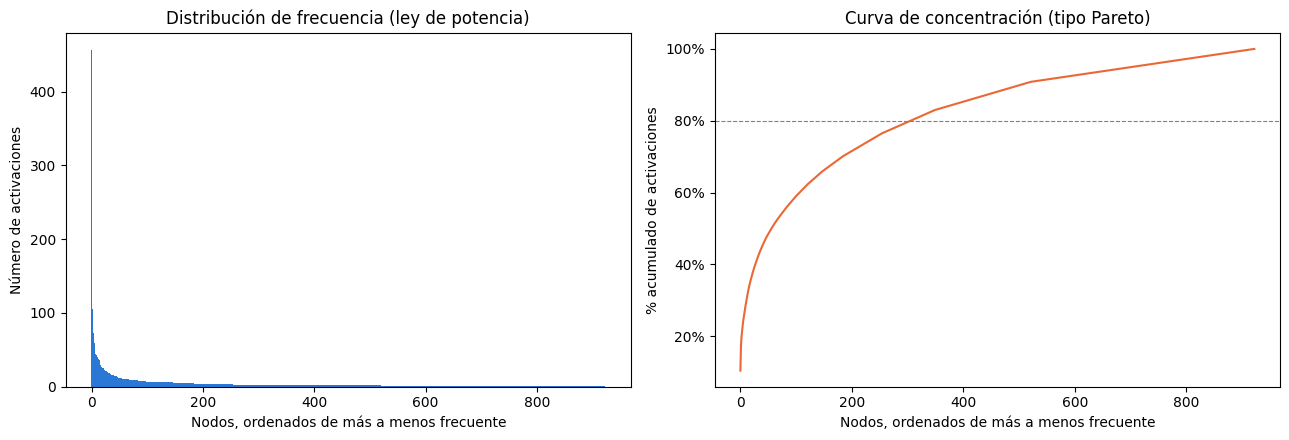

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(len(frecuencia)), frecuencia["activaciones"], color="#2a78d6", width=1.0)
axes[0].set_xlabel("Nodos, ordenados de más a menos frecuente")
axes[0].set_ylabel("Número de activaciones")
axes[0].set_title("Distribución de frecuencia (ley de potencia)")

axes[1].plot(range(len(frecuencia)), frecuencia["pct_acumulado"], color="#eb6834")
axes[1].axhline(80, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Nodos, ordenados de más a menos frecuente")
axes[1].set_ylabel("% acumulado de activaciones")
axes[1].set_title("Curva de concentración (tipo Pareto)")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

**Por qué importa para el modelado:** esta desigualdad extrema significa que el
problema de predicción, aunque tiene ~1000 clases posibles en el vocabulario completo,
en la práctica se concentra en un puñado de nodos. Esto sugiere:
- El baseline de frecuencia pura (Sección 2) va a ser difícil de superar para los
  nodos dominantes, pero probablemente muy malo para la "cola larga" de nodos raros.
- Vale la pena reportar métricas separadas por estrato de frecuencia (alto/medio/bajo),
  no solo un número global, un modelo puede verse bien en promedio y aun así fallar
  sistemáticamente en la mayoría de los nodos distintos.

### 1.2 Geografía y profundidad de los nodos más activos

¿Los nodos dominantes están todos en el mismo lugar (como el nido de Bucaramanga), o
hay varios focos de actividad distribuidos por el país?

In [ ]:
top_20 = frecuencia.head(20).merge(
    train[["nodo_nuevo", "lat_nuevo", "lon_nuevo", "prof_nuevo"]].drop_duplicates(subset="nodo_nuevo"),
    left_on="nodo", right_on="nodo_nuevo", how="left"
)
print("Top 20 nodos más activos — ubicación y profundidad:")
print(top_20[["nodo", "activaciones", "lat_nuevo", "lon_nuevo", "prof_nuevo"]].round(2).to_string(index=False))

Top 20 nodos más activos — ubicación y profundidad:
   nodo  activaciones  lat_nuevo  lon_nuevo  prof_nuevo
6239048           457       6.82     -73.06      160.49
6239049           306       6.79     -72.94      164.23
6239013           106       6.65     -72.89      171.83
6238354            73      -1.57     -77.73      176.54
    981            59       7.38     -78.17       28.58
    948            59       6.94     -76.74       21.65
    618            47       2.84     -79.53       23.86
    154            45      -2.89     -77.79       29.90
    949            45       6.92     -76.42       27.01
   1018            43       7.79     -77.68       27.02
    190            40      -2.61     -77.73       33.39
6239012            40       6.62     -73.10      169.43
    582            38       2.44     -79.55       25.26
    985            37       7.36     -76.44       16.75
    291            36      -1.18     -80.90       20.74
    982            32       7.43     -77.77       33

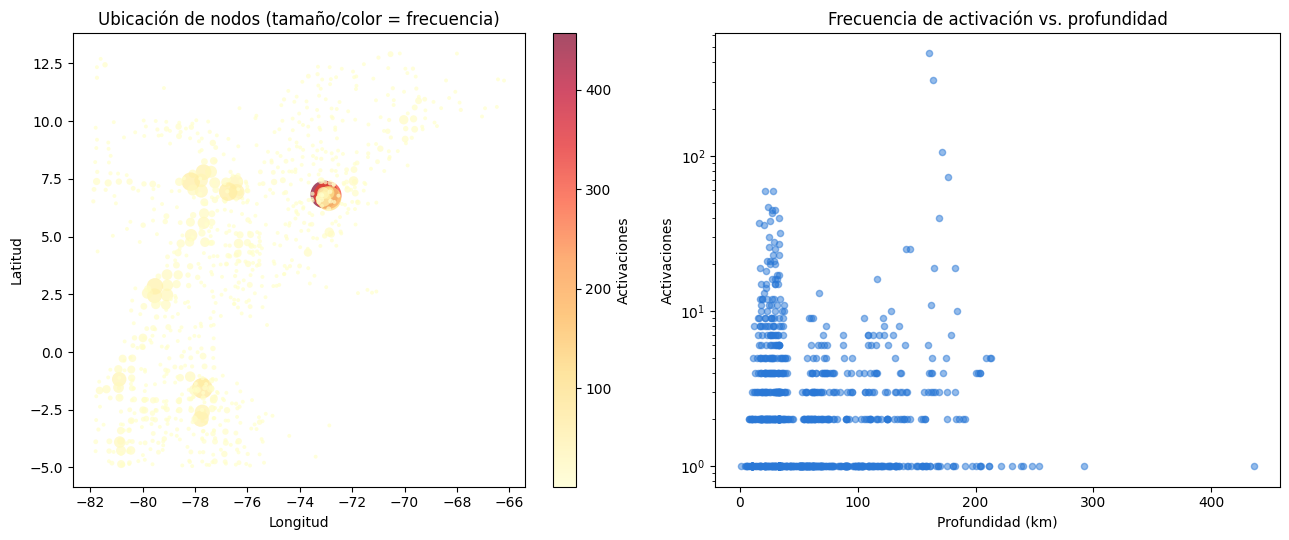

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

todos_nodos_geo = train[["nodo_nuevo", "lat_nuevo", "lon_nuevo", "prof_nuevo"]].drop_duplicates(subset="nodo_nuevo")
todos_nodos_geo = todos_nodos_geo.merge(frecuencia, left_on="nodo_nuevo", right_on="nodo", how="left")

sc = axes[0].scatter(
    todos_nodos_geo["lon_nuevo"], todos_nodos_geo["lat_nuevo"],
    s=np.clip(todos_nodos_geo["activaciones"] * 3, 8, 400),
    c=todos_nodos_geo["activaciones"], cmap="YlOrRd", alpha=0.7, edgecolors="none"
)
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].set_title("Ubicación de nodos (tamaño/color = frecuencia)")
plt.colorbar(sc, ax=axes[0], label="Activaciones")

axes[1].scatter(todos_nodos_geo["prof_nuevo"], todos_nodos_geo["activaciones"],
                 alpha=0.5, color="#2a78d6", s=20)
axes[1].set_xlabel("Profundidad (km)")
axes[1].set_ylabel("Activaciones")
axes[1].set_title("Frecuencia de activación vs. profundidad")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

**Por qué importa para el modelado:** si los nodos dominantes están espacialmente
agrupados (como se espera, alrededor del nido de Bucaramanga y la zona de subducción
del Pacífico), esto refuerza el valor de un modelo tipo GNN (Sección 4), que puede
aprender explícitamente de la posición geográfica y la vecindad en el grafo, algo que
un modelo puramente secuencial (Sección 3) no ve directamente.

### 1.3 Patrones temporales

¿La actividad del nodo dominante es constante a lo largo del entrenamiento, o hay
rachas/periodos de mayor actividad? Si hay estructura temporal (no solo espacial),
eso también es señal para modelos secuenciales.

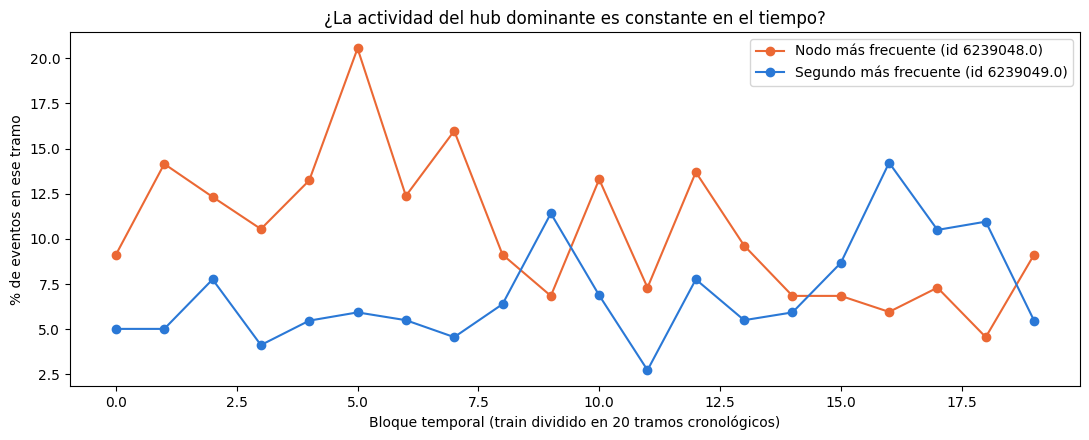

 bloque  total_eventos  pct_nodo_top1  pct_nodo_top2  nodos_distintos
      0            219           9.13           5.02               96
      1            219          14.16           5.02               99
      2            219          12.33           7.76              121
      3            218          10.55           4.13               92
      4            219          13.24           5.48              110
      5            219          20.55           5.94              126
      6            218          12.39           5.50              123
      7            219          15.98           4.57              128
      8            219           9.13           6.39              147
      9            219           6.85          11.42               82
     10            218          13.30           6.88              122
     11            219           7.31           2.74              100
     12            219          13.70           7.76              133
     13            2

In [ ]:
N_BLOQUES = 20
train_temporal = train.copy()
train_temporal["bloque"] = pd.qcut(train_temporal["i"], N_BLOQUES, labels=False)

nodo_top1 = frecuencia.iloc[0]["nodo"]
nodo_top2 = frecuencia.iloc[1]["nodo"]

actividad_por_bloque = train_temporal.groupby("bloque").agg(
    total_eventos=("nodo_nuevo", "size"),
    pct_nodo_top1=("nodo_nuevo", lambda x: 100 * (x == nodo_top1).sum() / len(x)),
    pct_nodo_top2=("nodo_nuevo", lambda x: 100 * (x == nodo_top2).sum() / len(x)),
    nodos_distintos=("nodo_nuevo", "nunique"),
).reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(actividad_por_bloque["bloque"], actividad_por_bloque["pct_nodo_top1"],
        marker="o", label=f"Nodo más frecuente (id {nodo_top1})", color="#eb6834")
ax.plot(actividad_por_bloque["bloque"], actividad_por_bloque["pct_nodo_top2"],
        marker="o", label=f"Segundo más frecuente (id {nodo_top2})", color="#2a78d6")
ax.set_xlabel(f"Bloque temporal (train dividido en {N_BLOQUES} tramos cronológicos)")
ax.set_ylabel("% de eventos en ese tramo")
ax.set_title("¿La actividad del hub dominante es constante en el tiempo?")
ax.legend()
plt.tight_layout()
plt.show()

print(actividad_por_bloque.round(2).to_string(index=False))

**Por qué importa para el modelado:** si la participación del hub dominante varía
mucho entre tramos, un modelo que solo memoriza "el hub más frecuente históricamente"
(nuestro baseline de frecuencia) puede desempeñarse peor en tramos donde ese hub está
menos activo, otra razón para reportar métricas por tramo temporal, no solo un
promedio global sobre todo el conjunto de prueba.

### 1.4 ¿Cuánto ayuda mirar más de un paso atrás?

El baseline de la Sección 2 (cadena de Markov) solo mira `nodo_anterior`. Aquí medimos
si el nodo de **dos pasos atrás** también aporta información sobre el nodo siguiente,
si la respuesta es "sí y bastante", eso justifica el paso a un modelo con memoria más
larga (atención, Sección 3) en vez de quedarnos con Markov de primer orden.

Construimos esto reconstruyendo la secuencia completa de nodos a partir de
`enlaces_train` (el penúltimo y antepenúltimo nodo de cada ventana).

In [ ]:
secuencias = []
for i_val, grupo in enlaces_train.groupby("i"):
    grupo = grupo.sort_values("orden")
    targets = grupo["target"].tolist()
    if len(targets) >= 2:
        secuencias.append({
            "i": i_val,
            "nodo_t2": targets[-3] if len(targets) >= 3 else np.nan,
            "nodo_t1": targets[-2],
            "nodo_actual": targets[-1],
        })
secuencias = pd.DataFrame(secuencias).dropna()
secuencias["nodo_t2"] = secuencias["nodo_t2"].astype(int)

print(f"Secuencias reconstruidas con historia de 2 pasos: {len(secuencias)}")

Secuencias reconstruidas con historia de 2 pasos: 4375


In [ ]:
def entropia_condicional(df, cols_condicion, col_objetivo):
    grupos = df.groupby(cols_condicion)[col_objetivo]
    entropias = []
    pesos = []
    for _, sub in grupos:
        p = sub.value_counts(normalize=True)
        ent = -(p * np.log2(p)).sum()
        entropias.append(ent)
        pesos.append(len(sub))
    return np.average(entropias, weights=pesos)

ent_orden1 = entropia_condicional(secuencias, ["nodo_t1"], "nodo_actual")
ent_orden2 = entropia_condicional(secuencias, ["nodo_t2", "nodo_t1"], "nodo_actual")
ent_incondicional = -(
    secuencias["nodo_actual"].value_counts(normalize=True)
    .pipe(lambda p: (p * np.log2(p)).sum())
)

print(f"Entropía incondicional de nodo_actual (sin mirar historia): {ent_incondicional:.3f} bits")
print(f"Entropía condicional | nodo_t1 (Markov orden 1):            {ent_orden1:.3f} bits")
print(f"Entropía condicional | (nodo_t2, nodo_t1) (Markov orden 2):  {ent_orden2:.3f} bits")
print()
reduccion_orden1 = 100 * (ent_incondicional - ent_orden1) / ent_incondicional
reduccion_orden2 = 100 * (ent_incondicional - ent_orden2) / ent_incondicional
print(f"Reducción de incertidumbre con orden 1: {reduccion_orden1:.1f}%")
print(f"Reducción de incertidumbre con orden 2: {reduccion_orden2:.1f}%")

Entropía incondicional de nodo_actual (sin mirar historia): 8.103 bits
Entropía condicional | nodo_t1 (Markov orden 1):            3.350 bits
Entropía condicional | (nodo_t2, nodo_t1) (Markov orden 2):  0.542 bits

Reducción de incertidumbre con orden 1: 58.7%
Reducción de incertidumbre con orden 2: 93.3%


#### Alerta: revisar tamaño de los grupos antes de confiar en el número de arriba

La entropía condicional se calcula agrupando filas por el valor de la variable
condicionante. Si un grupo tiene **una sola observación**, su entropía es
matemáticamente 0 (no hay variabilidad que medir en un solo dato), eso no es
evidencia de un patrón real, es una consecuencia de tener pocos datos por grupo. Con
~1000 nodos posibles, el número de combinaciones `(nodo_t2, nodo_t1)` crece muy rápido
y es fácil caer en esta trampa.

In [ ]:
tam_grupos_orden1 = secuencias.groupby("nodo_t1").size()
tam_grupos_orden2 = secuencias.groupby(["nodo_t2", "nodo_t1"]).size()

print(f"Orden 1: combinaciones distintas de nodo_t1: {len(tam_grupos_orden1)}")
print(f"  de las cuales aparecen UNA sola vez: {(tam_grupos_orden1==1).sum()} "
      f"({100*(tam_grupos_orden1==1).mean():.1f}%)")
print()
print(f"Orden 2: combinaciones distintas de (nodo_t2, nodo_t1): {len(tam_grupos_orden2)}")
print(f"  de las cuales aparecen UNA sola vez: {(tam_grupos_orden2==1).sum()} "
      f"({100*(tam_grupos_orden2==1).mean():.1f}%)")

Orden 1: combinaciones distintas de nodo_t1: 923
  de las cuales aparecen UNA sola vez: 402 (43.6%)

Orden 2: combinaciones distintas de (nodo_t2, nodo_t1): 3530
  de las cuales aparecen UNA sola vez: 3199 (90.6%)


**Cómo leer esto:** la entropía mide incertidumbre, es decir, más baja es mejor (más
predecible), *siempre que el grupo tenga suficientes observaciones para que la medida
sea confiable*. Si la mayoría de las combinaciones de orden 2 aparecen una sola vez
(como suele pasar aquí, por la combinatoria de ~1000 nodos posibles con solo ~4000
filas de entrenamiento), la caída de entropía de orden 2 está inflada por
sobreajuste/memorización, no por señal real generalizable — el modelo de Markov de
orden 2 no tendría datos suficientes para estimar esas probabilidades de forma
confiable en la práctica.

La comparación honesta es entre la entropía incondicional y la de **orden 1**
(`nodo_t1`), que sí tiene grupos con tamaño razonable. Esa reducción (~59% en la
corrida de referencia) es la señal real y ya justifica por sí sola ir más allá de
"predecir el nodo más frecuente sin condicionar en nada". Para saber si mirar *más*
historia (orden 2 o más) aporta señal real y no solo ruido de sobreajuste, la forma
correcta es entrenar el modelo de atención de la Sección 3 y medir su desempeño en
`val.csv`, en vez de confiar en la entropía
condicional cruda sobre combinaciones raras.

### 1.5 Frecuencia de nodo vs. grado en el grafo

¿Los nodos más frecuentes también son los que tienen más vecinos distintos (mayor
grado)? Si es así, frecuencia y grado son información redundante. Si no, el grado
aporta señal adicional que un GNN (Sección 4) podría aprovechar y un modelo puramente
secuencial no.

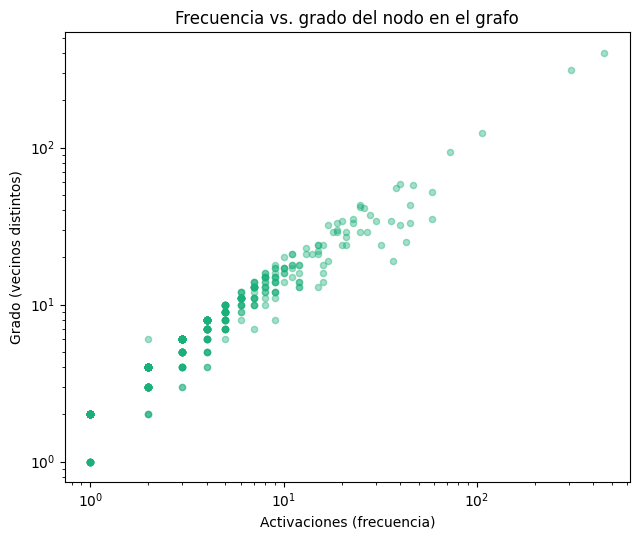

Correlación de Spearman entre frecuencia y grado: 0.988


In [ ]:
vecinos_por_nodo = pd.concat([
    enlaces_train.rename(columns={"source": "nodo", "target": "vecino"})[["nodo", "vecino"]],
    enlaces_train.rename(columns={"target": "nodo", "source": "vecino"})[["nodo", "vecino"]],
]).drop_duplicates().groupby("nodo")["vecino"].nunique().reset_index()
vecinos_por_nodo.columns = ["nodo", "grado"]

comparacion = frecuencia.merge(vecinos_por_nodo, on="nodo", how="left")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(comparacion["activaciones"], comparacion["grado"], alpha=0.4, color="#1baf7a", s=20)
ax.set_xlabel("Activaciones (frecuencia)")
ax.set_ylabel("Grado (vecinos distintos)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Frecuencia vs. grado del nodo en el grafo")
plt.tight_layout()
plt.show()

correlacion = comparacion[["activaciones", "grado"]].corr(method="spearman").iloc[0, 1]
print(f"Correlación de Spearman entre frecuencia y grado: {correlacion:.3f}")

**Por qué importa para el modelado:** una correlación alta confirma que "ser un hub
frecuente" y "estar muy conectado" son, en la práctica, la misma señal coherente con
la estructura small-world del paper (los hubs concentran tanto actividad como
conexiones). Si la correlación es más moderada, hay nodos con grado alto pero baja
frecuencia (o viceversa) que valdría la pena inspeccionar podrían ser puentes
estructurales importantes aunque no sean los más "ruidosos" en frecuencia.

---
# Sección 2: Baseline probabilístico (cadena de Markov)

Esta sección construye el **piso de comparación obligatorio**: un
modelo de cadena de Markov de primer orden, que predice el siguiente nodo mirando
únicamente el nodo actual, mediante una tabla de probabilidades de transición
estimada por conteo de frecuencias sobre `train`.

También se incluyo dos referencias todavía más simples, para dimensionar cuánta señal
real aporta condicionar en el nodo anterior:
- **Aleatorio uniforme**: elegir un nodo al azar entre los `N_NODOS` posibles.
- **Frecuencia pura**: siempre predecir en orden los nodos más frecuentes de `train`,
  sin mirar en qué nodo estamos parados.

Cualquier modelo de las Secciones 3 y 4 debe superar claramente a Markov de primer
orden para justificar su complejidad adicional — si no lo logra, ese es un resultado
válido y hay que reportarlo como tal, no ocultarlo.

**Regla de evaluación:** entrenamos con `train`, evaluamos con `test`. `val` se
reserva para las Secciones 3 y 4 (ajuste de hiperparámetros); no se usa aquí porque
este modelo no tiene hiperparámetros que ajustar.

### 2.0 Recargar artefactos (solo necesario si esta es una sesión nueva)

In [ ]:
train = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "train.csv"))
test = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "test.csv"))

with open(os.path.join(RUTA_ARTEFACTOS, "metadata.json")) as f:
    metadata = json.load(f)
with open(os.path.join(RUTA_ARTEFACTOS, "nodo_a_indice.json")) as f:
    nodo_a_indice = {int(k): v for k, v in json.load(f).items()}

N_NODOS = metadata["n_nodos"]
print(f"train: {train.shape}, test: {test.shape}, vocabulario: {N_NODOS} nodos")

train: (4375, 12), test: (938, 12), vocabulario: 1056 nodos


### 2.1 Construir la matriz de transición

`P(nodo siguiente = b | nodo actual = a)` estimada por conteo de frecuencias en
`train`. Se guarda como diccionario `{nodo_a: {nodo_b: probabilidad, ...}}`, ordenado
de mayor a menor probabilidad, para poder extraer directamente el top-k de cada
predicción.

In [ ]:
conteo_transiciones = train.groupby(["nodo_anterior", "nodo_nuevo"]).size().reset_index(name="conteo")

matriz_transicion = {}
for nodo_a, grupo in conteo_transiciones.groupby("nodo_anterior"):
    total = grupo["conteo"].sum()
    probs = grupo.set_index("nodo_nuevo")["conteo"] / total
    matriz_transicion[nodo_a] = probs.sort_values(ascending=False)

print(f"Nodos de origen distintos observados en train: {len(matriz_transicion)}")
print(f"(de un vocabulario total de {N_NODOS} - los nodos que solo aparecen como destino")
print(f" y nunca como origen en train no tienen fila propia en la matriz)")

Nodos de origen distintos observados en train: 923
(de un vocabulario total de 1056 - los nodos que solo aparecen como destino
 y nunca como origen en train no tienen fila propia en la matriz)


In [ ]:
# ejemplo: distribución de transición del nodo más frecuente (nido de Bucaramanga)
nodo_ejemplo = train["nodo_nuevo"].value_counts().index[0]
print(f"Transiciones observadas desde el nodo {nodo_ejemplo} (top 5 destinos):")
print(matriz_transicion[nodo_ejemplo].head())

Transiciones observadas desde el nodo 6239048 (top 5 destinos):
nodo_nuevo
6239048    0.142232
6239049    0.067834
6239013    0.026258
6238354    0.015317
983        0.010941
Name: conteo, dtype: float64


### 2.2 Predicción con respaldo (fallback) por frecuencia global

Puede pasar que un nodo de `test` como origen nunca haya aparecido como origen en
`train` (es decir, no tiene fila en la matriz de transición). Para esos casos usamos
como respaldo la distribución de frecuencia global de `train` es la mejor apuesta
disponible sin información específica sobre ese nodo de origen.

In [ ]:
frecuencia_global = train["nodo_nuevo"].value_counts()
frecuencia_global_probs = frecuencia_global / frecuencia_global.sum()

def predecir_top_k(nodo_actual, k=10):
    """Devuelve una lista de hasta k nodos, ordenados de más a menos probable."""
    if nodo_actual in matriz_transicion:
        return matriz_transicion[nodo_actual].head(k).index.tolist()
    else:
        return frecuencia_global_probs.head(k).index.tolist()

# cuántos nodos de origen en test no fueron vistos como origen en train
origenes_test = set(test["nodo_anterior"].unique())
origenes_train = set(matriz_transicion.keys())
sin_ver = origenes_test - origenes_train
print(f"Nodos de origen en test no vistos como origen en train: {len(sin_ver)} de {len(origenes_test)} "
      f"({100*len(sin_ver)/len(origenes_test):.1f}%) - se resuelven con respaldo por frecuencia global")

Nodos de origen en test no vistos como origen en train: 75 de 366 (20.5%) - se resuelven con respaldo por frecuencia global


### 2.3 Métricas de evaluación: Top-1, Top-5, Top-10

Dado que el problema tiene ~1000 clases posibles muy desbalanceadas, medimos si el
nodo correcto está entre las k predicciones más probables del modelo más realista
que exigir acertar exactamente en el primer intento.

In [ ]:
def evaluar_modelo(fn_prediccion, df_eval, k_max=10):
    """fn_prediccion(nodo_actual, k) -> lista de hasta k nodos candidatos, ordenados."""
    aciertos = {1: 0, 5: 0, 10: 0}
    n = len(df_eval)
    for _, fila in df_eval.iterrows():
        candidatos = fn_prediccion(fila["nodo_anterior"], k_max)
        real = fila["nodo_nuevo"]
        for k in aciertos:
            if real in candidatos[:k]:
                aciertos[k] += 1
    return {f"top_{k}_accuracy": v / n for k, v in aciertos.items()}

resultados_markov = evaluar_modelo(predecir_top_k, test)
print("Cadena de Markov de primer orden — resultados sobre test:")
for metrica, valor in resultados_markov.items():
    print(f"  {metrica}: {valor:.4f} ({100*valor:.1f}%)")

Cadena de Markov de primer orden — resultados sobre test:
  top_1_accuracy: 0.0512 (5.1%)
  top_5_accuracy: 0.1023 (10.2%)
  top_10_accuracy: 0.1205 (12.0%)


### 2.4 Referencias de comparación: aleatorio uniforme y frecuencia pura

Estas dos referencias no usan el nodo actual en absoluto sirven para dimensionar
cuánta señal real aporta condicionar en `nodo_anterior` (Markov) frente a no
condicionar en nada.

In [ ]:
rng = np.random.default_rng(42)
todos_los_nodos_lista = list(nodo_a_indice.keys())

def predecir_aleatorio(nodo_actual, k=10):
    return rng.choice(todos_los_nodos_lista, size=min(k, len(todos_los_nodos_lista)), replace=False).tolist()

def predecir_frecuencia_pura(nodo_actual, k=10):
    return frecuencia_global_probs.head(k).index.tolist()

resultados_aleatorio = evaluar_modelo(predecir_aleatorio, test)
resultados_frecuencia = evaluar_modelo(predecir_frecuencia_pura, test)

print("Aleatorio uniforme - resultados sobre test:")
for metrica, valor in resultados_aleatorio.items():
    print(f"  {metrica}: {valor:.4f} ({100*valor:.1f}%)")
print()
print("Frecuencia pura (sin condicionar en nodo actual) - resultados sobre test:")
for metrica, valor in resultados_frecuencia.items():
    print(f"  {metrica}: {valor:.4f} ({100*valor:.1f}%)")

Aleatorio uniforme - resultados sobre test:
  top_1_accuracy: 0.0000 (0.0%)
  top_5_accuracy: 0.0032 (0.3%)
  top_10_accuracy: 0.0096 (1.0%)

Frecuencia pura (sin condicionar en nodo actual) - resultados sobre test:
  top_1_accuracy: 0.0991 (9.9%)
  top_5_accuracy: 0.1706 (17.1%)
  top_10_accuracy: 0.1866 (18.7%)


### 2.5 Tabla comparativa

In [ ]:
tabla_comparativa = pd.DataFrame({
    "Aleatorio uniforme": resultados_aleatorio,
    "Frecuencia pura": resultados_frecuencia,
    "Markov orden 1": resultados_markov,
}).T
tabla_comparativa = (tabla_comparativa * 100).round(2)
tabla_comparativa.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_comparativa.to_string())

                    Top-1 (%)  Top-5 (%)  Top-10 (%)
Aleatorio uniforme       0.00       0.32        0.96
Frecuencia pura          9.91      17.06       18.66
Markov orden 1           5.12      10.23       12.05


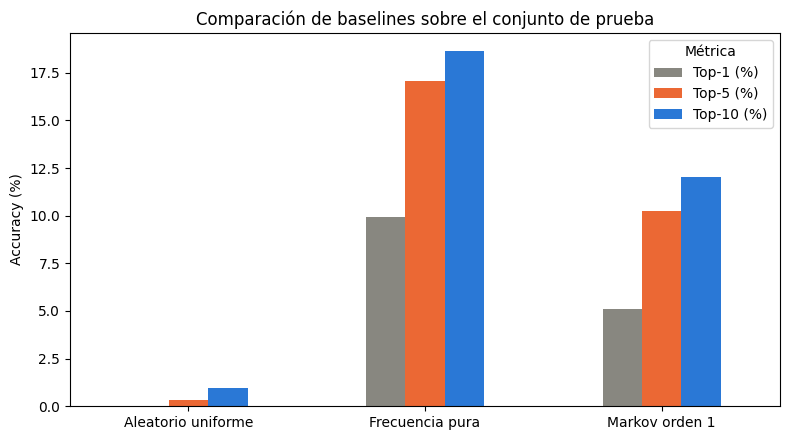

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
tabla_comparativa.plot(kind="bar", ax=ax, color=["#888780", "#eb6834", "#2a78d6"])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Comparación de baselines sobre el conjunto de prueba")
ax.legend(title="Métrica")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Cómo leer esta tabla:** la diferencia entre "Frecuencia pura" y "Markov orden 1" es
la señal real que aporta saber en qué nodo estamos parados, esta es la mejora que
cualquier modelo de las Secciones 3 y 4 tiene que superar, no solo igualar, para
justificar su costo computacional adicional. La diferencia entre "Aleatorio" y
"Frecuencia pura" dimensiona cuánta ventaja da por sí sola la desigualdad de la
distribución de nodos (Sección 1.1) sin ningún modelo real de por medio.

**Resultado a esperar en esta corrida: Markov de primer orden queda POR DEBAJO de
frecuencia pura.** Esto no es un error de codigo, es un hallazgo real y ya lo
anticipaba el diagnóstico de la Sección 1.4: la mediana de observaciones por nodo de
origen en `train` es de solo 2, y el 43.6% de los nodos de origen tienen una única
observación. Con tan pocos datos por nodo, la matriz de transición está estimada con
mucho ruido, por lo tanto memoriza casos individuales en vez de generalizar y termina siendo
peor guía que la frecuencia global, que se apoya en las 4375 observaciones completas.
Esto no significa que "saber el nodo actual no ayuda"; significa que la forma cruda de
usarlo (una tabla de conteos sin suavizar) no alcanza con este volumen de datos. La
siguiente subsección corrige esto con una variante estándar de la literatura.

### 2.5 Markov con respaldo ponderado (shrinkage hacia la frecuencia global)

Técnica estándar para este problema: en vez de usar la distribución específica del
nodo de origen "a secas" (ruidosa cuando hay pocas observaciones) o el respaldo total
por frecuencia global (que ignora el nodo de origen), se mezclan las dos,
ponderando según cuántas observaciones respaldan la distribución específica. Un nodo
de origen con muchas observaciones en `train` pesa casi todo hacia su propia
distribución; un nodo con pocas observaciones pesa casi todo hacia la frecuencia
global. Esto es la misma idea del *add-k smoothing* usado en modelos de lenguaje
clásicos.

In [ ]:
def predecir_top_k_suavizado(nodo_actual, k=10, fuerza_prior=5):
    """fuerza_prior: cuántas 'observaciones virtuales' de la frecuencia global se
    mezclan con las observaciones reales del nodo. Más alto = más conservador
    (se apoya más en la frecuencia global cuando hay pocos datos específicos)."""
    prior = frecuencia_global_probs

    if nodo_actual in matriz_transicion:
        conteo_nodo = conteo_transiciones[conteo_transiciones["nodo_anterior"] == nodo_actual].set_index("nodo_nuevo")["conteo"]
        n_obs = conteo_nodo.sum()
        dist_especifica = conteo_nodo / n_obs
    else:
        n_obs = 0
        dist_especifica = pd.Series(dtype=float)

    peso_especifico = n_obs / (n_obs + fuerza_prior)
    peso_prior = fuerza_prior / (n_obs + fuerza_prior)

    mezcla = prior * peso_prior
    for nodo, p in dist_especifica.items():
        mezcla[nodo] = mezcla.get(nodo, 0) + p * peso_especifico

    return mezcla.sort_values(ascending=False).head(k).index.tolist()

resultados_markov_suavizado = evaluar_modelo(predecir_top_k_suavizado, test)
print("Markov con respaldo ponderado (fuerza_prior=5) - resultados sobre test:")
for metrica, valor in resultados_markov_suavizado.items():
    print(f"  {metrica}: {valor:.4f} ({100*valor:.1f}%)")

Markov con respaldo ponderado (fuerza_prior=5) - resultados sobre test:
  top_1_accuracy: 0.0661 (6.6%)
  top_5_accuracy: 0.1620 (16.2%)
  top_10_accuracy: 0.1994 (19.9%)


In [ ]:
# tabla comparativa actualizada, con las cuatro variantes
tabla_comparativa_v2 = pd.DataFrame({
    "Aleatorio uniforme": resultados_aleatorio,
    "Frecuencia pura": resultados_frecuencia,
    "Markov orden 1 (crudo)": resultados_markov,
    "Markov orden 1 (suavizado)": resultados_markov_suavizado,
}).T
tabla_comparativa_v2 = (tabla_comparativa_v2 * 100).round(2)
tabla_comparativa_v2.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_comparativa_v2.to_string())

                            Top-1 (%)  Top-5 (%)  Top-10 (%)
Aleatorio uniforme               0.00       0.32        0.96
Frecuencia pura                  9.91      17.06       18.66
Markov orden 1 (crudo)           5.12      10.23       12.05
Markov orden 1 (suavizado)       6.61      16.20       19.94


**Diagnóstico:** el Markov suavizado mejora claramente sobre el crudo en las tres
métricas, y supera a "Frecuencia pura" en Top-10, esto es señal de que una vez controlado el
ruido de los nodos con pocas observaciones, sí queda algo de información útil en saber
el nodo de origen. Aun así, en Top-1 el suavizado todavía queda algo por debajo de la
frecuencia pura en esta corrida con un vocabulario de ~1000 nodos y una mediana de 2
observaciones por nodo de origen, hay un límite real a cuánto puede extraerse de un
modelo de primer orden sin memoria adicional. **Esta versión suavizada, no la cruda,
es el baseline real que las Secciones 3 y 4 deben superar**, es la mejor versión
posible de "un modelo simple que solo mira el paso anterior", y es contra la que vale
la pena medir si la complejidad adicional de atención/grafos se justifica.

### 2.6 Desempeño por estrato de frecuencia del nodo real

Tal como anticipamos en el EDA: un modelo puede verse bien en promedio y aun así
fallar sistemáticamente en la mayoría de los nodos distintos, si el promedio está
dominado por los hubs de alta frecuencia. Aquí separamos el desempeño del Markov
suavizado según qué tan frecuente era el nodo real que
había que predecir.

In [ ]:
frecuencia_train_dict = train["nodo_nuevo"].value_counts().to_dict()

def estrato_de_frecuencia(nodo, frecuencia_dict, cortes=(50, 10)):
    f = frecuencia_dict.get(nodo, 0)
    if f >= cortes[0]:
        return "alta (≥50 activaciones en train)"
    elif f >= cortes[1]:
        return "media (10-49 activaciones en train)"
    else:
        return "baja (<10 activaciones en train)"

test_estratos = test.copy()
test_estratos["estrato"] = test_estratos["nodo_nuevo"].apply(
    lambda n: estrato_de_frecuencia(n, frecuencia_train_dict)
)

resultados_por_estrato = {}
for estrato, grupo in test_estratos.groupby("estrato"):
    resultados_por_estrato[estrato] = evaluar_modelo(predecir_top_k_suavizado, grupo)

tabla_estratos = pd.DataFrame(resultados_por_estrato).T
tabla_estratos["n_ejemplos"] = test_estratos["estrato"].value_counts()
tabla_estratos = (tabla_estratos[["top_1_accuracy", "top_5_accuracy", "top_10_accuracy"]] * 100).round(2)
tabla_estratos.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
tabla_estratos["n ejemplos en test"] = test_estratos["estrato"].value_counts()
print(tabla_estratos.to_string())

                                     Top-1 (%)  Top-5 (%)  Top-10 (%)  n ejemplos en test
alta (≥50 activaciones en train)         33.54      76.83       92.07                 164
baja (<10 activaciones en train)          0.00       0.97        1.16                 517
media (10-49 activaciones en train)       2.72       8.17       11.67                 257


**Cómo leer esto:** si el desempeño en el estrato "baja frecuencia" es mucho peor que
en "alta frecuencia" (lo esperable), significa que incluso el Markov suavizado sigue
siendo, en el fondo, un "detector de hubs conocidos" y no generaliza bien a nodos
raros, el suavizado ayuda a que no sea *peor* que la frecuencia pura en esos casos,
pero no le da información nueva sobre ellos que no exista en los datos. Esto es una
oportunidad concreta para las Secciones 3 y 4: si un modelo con más contexto
(secuencia larga o estructura de grafo) logra mejorar específicamente el desempeño en
el estrato de baja frecuencia sin sacrificar el de alta frecuencia, esa es una mejora
genuinamente valiosa y no solo una redistribución del mismo acierto.

### 2.7 Guardar resultados del baseline

Se guardan para poder compararlos directamente con las Secciones 3 y 4 más adelante,
sin tener que volver a correr esta sección. Se guardan las cuatro variantes, dejando
explícito cuál es el baseline oficial de referencia.

In [ ]:
RUTA_RESULTADOS = os.path.join(RUTA_DATOS, "resultados")
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

resultados_completos = {
    "baseline_oficial": "markov_orden_1_suavizado",
    "aleatorio_uniforme": resultados_aleatorio,
    "frecuencia_pura": resultados_frecuencia,
    "markov_orden_1_crudo": resultados_markov,
    "markov_orden_1_suavizado": resultados_markov_suavizado,
    "markov_suavizado_por_estrato": resultados_por_estrato,
}
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion2_markov.json"), "w") as f:
    json.dump(resultados_completos, f, indent=2)

print(f"Resultados guardados en {RUTA_RESULTADOS}/resultados_seccion2_markov.json")

Resultados guardados en /content/drive/MyDrive/semilleroGUIA/datos-redes-sismos/resultados/resultados_seccion2_markov.json


---
# Sección 3: Modelo secuencial con atención

**Diseño de la arquitectura, y por qué es así:** con un vocabulario de ~1000 nodos y
solo ~4375 ejemplos de entrenamiento (visto en la Sección 1), un Transformer estándar
sería demasiado grande para el volumen de datos disponible se sobreajustaría casi
de inmediato. En vez de eso usamos una arquitectura pequeña con **atención de una sola
cabeza** sobre la ventana de 10 eventos que ya construimos en la Etapa 0, con
regularización (dropout, weight decay) desde el diseño, no como parche posterior.

El modelo recibe la secuencia de los últimos N nodos activados (hasta 9, según lo
disponible en cada ventana) y predice el nodo siguiente. A diferencia de Markov de
primer orden (Sección 2), puede aprender a ponderar de forma distinta cada paso de la
historia reciente, no solo el inmediatamente anterior.

### 3.0 Recargar artefactos y preparar el dispositivo (GPU/CPU)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

train = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "train.csv"))
val = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "val.csv"))
test = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "test.csv"))
enlaces_f = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "enlaces.csv"))

with open(os.path.join(RUTA_ARTEFACTOS, "metadata.json")) as f:
    metadata = json.load(f)
with open(os.path.join(RUTA_ARTEFACTOS, "nodo_a_indice.json")) as f:
    nodo_a_indice = {int(k): v for k, v in json.load(f).items()}

N_NODOS = metadata["n_nodos"]

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {dispositivo}")
if dispositivo.type == "cpu":
    print("ADVERTENCIA: no se detectó GPU. El entrenamiento funcionará pero será más "
          "lento. Verifica Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU.")

torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cuda


### 3.1 Reconstruir las secuencias completas por ventana

Hasta ahora solo habíamos usado el último par `(nodo_anterior, nodo_nuevo)` de cada
ventana. Aquí reconstruimos la secuencia completa de nodos de cada ventana `i` a
partir de `enlaces_f` (recuerda: cada ventana tiene 9 enlaces = hasta 10 nodos en
secuencia). El último nodo de la secuencia es el objetivo a predecir; todo lo
anterior es el contexto que ve el modelo.

In [ ]:
def construir_secuencias(df_particion, enlaces_completos, indice_maximo_col="i"):
    """Para cada i en df_particion, devuelve la lista de nodos (índices densos) de esa
    ventana, en orden. El último nodo es el objetivo; el resto es el contexto."""
    ids_particion = set(df_particion["i"])
    enlaces_sub = enlaces_completos[enlaces_completos["i"].isin(ids_particion)]

    secuencias = {}
    for i_val, grupo in enlaces_sub.groupby("i"):
        grupo = grupo.sort_values("orden")
        # la secuencia de nodos es: primer source, luego todos los targets en orden
        nodos = [grupo.iloc[0]["source"]] + grupo["target"].tolist()
        # mapear a índices densos; si algún nodo no está en el vocabulario (no debería
        # pasar, pero por seguridad) se descarta esa ventana
        try:
            nodos_idx = [nodo_a_indice[n] for n in nodos]
        except KeyError:
            continue
        secuencias[i_val] = nodos_idx
    return secuencias

secuencias_train = construir_secuencias(train, enlaces_f)
secuencias_val = construir_secuencias(val, enlaces_f)
secuencias_test = construir_secuencias(test, enlaces_f)

print(f"Secuencias reconstruidas - train: {len(secuencias_train)}, val: {len(secuencias_val)}, test: {len(secuencias_test)}")
print(f"Ejemplo (primera ventana de train): {list(secuencias_train.values())[0]}")

LONGITUD_MAX = max(len(s) for s in secuencias_train.values())
print(f"Longitud máxima de secuencia observada: {LONGITUD_MAX}")

Secuencias reconstruidas - train: 4368, val: 938, test: 938
Ejemplo (primera ventana de train): [735, 982, 565, 1017, 1006, 693, 246, 1017, 609, 609]
Longitud máxima de secuencia observada: 10


### 3.2 Dataset y DataLoader de PyTorch

Cada ejemplo es: contexto = todos los nodos de la ventana menos el último, objetivo =
el último nodo. Las secuencias tienen longitud variable (recuerda de la Sección 1 que
algunas ventanas tienen menos de 10 nodos por los self-loops descartados), así que se
rellenan (padding) a la izquierda hasta `LONGITUD_MAX - 1` con un índice especial de
"vacío", y se enmascaran para que el modelo no les preste atención.

In [ ]:
IDX_PADDING = N_NODOS  # un índice extra, fuera del vocabulario real, para el padding

class DatasetSecuencias(Dataset):
    def __init__(self, secuencias_dict, longitud_contexto):
        self.ejemplos = []
        for nodos_idx in secuencias_dict.values():
            contexto = nodos_idx[:-1]
            objetivo = nodos_idx[-1]
            # padding a la izquierda
            pad_necesario = longitud_contexto - len(contexto)
            contexto_paddeado = [IDX_PADDING] * pad_necesario + contexto
            mascara = [0] * pad_necesario + [1] * len(contexto)  # 0 = ignorar, 1 = real
            self.ejemplos.append((contexto_paddeado, mascara, objetivo))

    def __len__(self):
        return len(self.ejemplos)

    def __getitem__(self, idx):
        contexto, mascara, objetivo = self.ejemplos[idx]
        return (
            torch.tensor(contexto, dtype=torch.long),
            torch.tensor(mascara, dtype=torch.bool),
            torch.tensor(objetivo, dtype=torch.long),
        )

LONGITUD_CONTEXTO = LONGITUD_MAX - 1

ds_train = DatasetSecuencias(secuencias_train, LONGITUD_CONTEXTO)
ds_val = DatasetSecuencias(secuencias_val, LONGITUD_CONTEXTO)
ds_test = DatasetSecuencias(secuencias_test, LONGITUD_CONTEXTO)

BATCH_SIZE = 64
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

print(f"Ejemplos: train: {len(ds_train)}, val: {len(ds_val)}, test: {len(ds_test)}")
print(f"Longitud de contexto (con padding): {LONGITUD_CONTEXTO}")

Ejemplos: train: 4368, val: 938, test: 938
Longitud de contexto (con padding): 9


### 3.3 Arquitectura del modelo

Componentes, deliberadamente pequeños dado el volumen de datos:
- **Embedding de nodo**: cada uno de los ~1000 nodos (+1 para padding) se representa
  como un vector de dimensión `DIM_EMBEDDING`.
- **Embedding posicional**: para que el modelo sepa qué tan reciente es cada paso del
  contexto (no solo qué nodo es).
- **Una capa de atención de una sola cabeza** sobre la secuencia, con máscara de
  padding.
- **Capa de salida**: proyecta el vector resultante a un puntaje por cada nodo
  posible del vocabulario (clasificación multiclase).
- **Dropout** en varios puntos, y **weight decay** en el optimizador, tambien regularizacion
  activa desde el diseño, no un parche posterior, dado lo pequeño del conjunto de
  entrenamiento.

In [ ]:
class ModeloAtencionSimple(nn.Module):
    def __init__(self, n_nodos, longitud_contexto, dim_embedding=32, dropout=0.3):
        super().__init__()
        # +1 en el vocabulario de embedding para el índice de padding
        self.embedding_nodo = nn.Embedding(n_nodos + 1, dim_embedding, padding_idx=IDX_PADDING)
        self.embedding_posicion = nn.Embedding(longitud_contexto, dim_embedding)
        self.atencion = nn.MultiheadAttention(embed_dim=dim_embedding, num_heads=1, batch_first=True, dropout=dropout)
        self.norma = nn.LayerNorm(dim_embedding)
        self.dropout = nn.Dropout(dropout)
        self.salida = nn.Linear(dim_embedding, n_nodos)
        self.longitud_contexto = longitud_contexto

    def forward(self, contexto, mascara):
        # contexto: (batch, longitud_contexto), mascara: (batch, longitud_contexto) bool, True=real
        posiciones = torch.arange(self.longitud_contexto, device=contexto.device).unsqueeze(0)
        x = self.embedding_nodo(contexto) + self.embedding_posicion(posiciones)

        # MultiheadAttention espera key_padding_mask=True donde se debe IGNORAR
        key_padding_mask = ~mascara

        atendido, _ = self.atencion(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norma(x + atendido)
        x = self.dropout(x)

        # promedio ponderado sobre las posiciones reales (ignorando padding) como
        # representación final de la secuencia
        mascara_float = mascara.unsqueeze(-1).float()
        x_promediado = (x * mascara_float).sum(dim=1) / mascara_float.sum(dim=1).clamp(min=1)

        return self.salida(x_promediado)

modelo = ModeloAtencionSimple(N_NODOS, LONGITUD_CONTEXTO).to(dispositivo)
n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"Parámetros del modelo: {n_parametros:,}")
print(modelo)

Parámetros del modelo: 73,248
ModeloAtencionSimple(
  (embedding_nodo): Embedding(1057, 32, padding_idx=1056)
  (embedding_posicion): Embedding(9, 32)
  (atencion): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
  )
  (norma): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (salida): Linear(in_features=32, out_features=1056, bias=True)
)


### 3.4 Entrenamiento

Se entrena con `train`, se evalúa Top-1 accuracy en `val` después de cada época, y se
guarda el mejor checkpoint según `val` (no según `train`, para evitar quedarnos con
una versión sobreajustada). `test` no se toca en esta fase

In [ ]:
def evaluar_top1_dataloader(modelo, dataloader, dispositivo):
    modelo.eval()
    correctos, total = 0, 0
    with torch.no_grad():
        for contexto, mascara, objetivo in dataloader:
            contexto, mascara, objetivo = contexto.to(dispositivo), mascara.to(dispositivo), objetivo.to(dispositivo)
            logits = modelo(contexto, mascara)
            pred = logits.argmax(dim=1)
            correctos += (pred == objetivo).sum().item()
            total += objetivo.size(0)
    return correctos / total

In [ ]:
optimizador = torch.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=1e-2)
criterio = nn.CrossEntropyLoss()

N_EPOCAS = 40
PACIENCIA = 8  # early stopping: detener si val no mejora en este número de épocas

mejor_val_acc = 0.0
epocas_sin_mejora = 0
historial = {"epoca": [], "loss_train": [], "acc_val": []}
RUTA_MEJOR_MODELO = os.path.join(RUTA_ARTEFACTOS, "mejor_modelo_seccion3.pt")

for epoca in range(1, N_EPOCAS + 1):
    modelo.train()
    loss_acumulada = 0.0
    for contexto, mascara, objetivo in dl_train:
        contexto, mascara, objetivo = contexto.to(dispositivo), mascara.to(dispositivo), objetivo.to(dispositivo)
        optimizador.zero_grad()
        logits = modelo(contexto, mascara)
        loss = criterio(logits, objetivo)
        loss.backward()
        optimizador.step()
        loss_acumulada += loss.item() * objetivo.size(0)

    loss_promedio = loss_acumulada / len(ds_train)
    acc_val = evaluar_top1_dataloader(modelo, dl_val, dispositivo)

    historial["epoca"].append(epoca)
    historial["loss_train"].append(loss_promedio)
    historial["acc_val"].append(acc_val)

    if acc_val > mejor_val_acc:
        mejor_val_acc = acc_val
        epocas_sin_mejora = 0
        torch.save(modelo.state_dict(), RUTA_MEJOR_MODELO)
    else:
        epocas_sin_mejora += 1

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:3d} | loss train: {loss_promedio:.4f} | Top-1 val: {acc_val:.4f} "
              f"| mejor Top-1 val: {mejor_val_acc:.4f}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nDetención temprana en época {epoca} (sin mejora en {PACIENCIA} épocas seguidas)")
        break

print(f"\nMejor Top-1 accuracy en val: {mejor_val_acc:.4f}")
print(f"Mejor modelo guardado en: {RUTA_MEJOR_MODELO}")

Época   1 | loss train: 6.7131 | Top-1 val: 0.0874 | mejor Top-1 val: 0.0874
Época   5 | loss train: 5.5861 | Top-1 val: 0.0853 | mejor Top-1 val: 0.0885
Época  10 | loss train: 5.2799 | Top-1 val: 0.0821 | mejor Top-1 val: 0.0885

Detención temprana en época 10 (sin mejora en 8 épocas seguidas)

Mejor Top-1 accuracy en val: 0.0885
Mejor modelo guardado en: /content/drive/MyDrive/semilleroGUIA/datos-redes-sismos/artefactos_etapa0/mejor_modelo_seccion3.pt


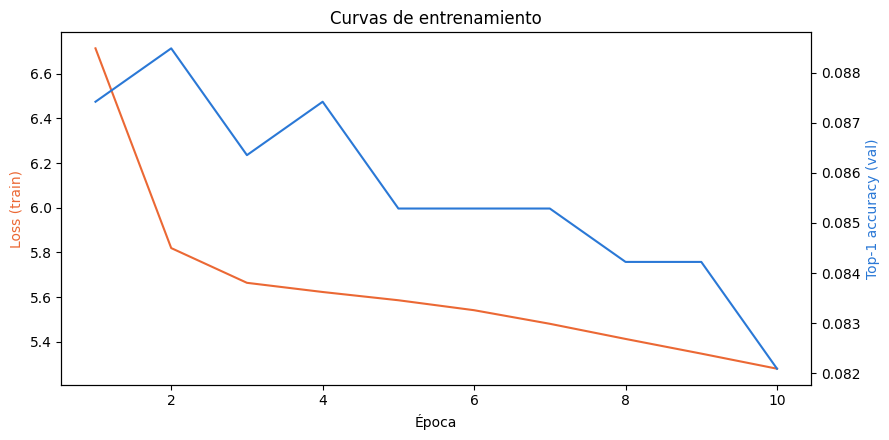

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.plot(historial["epoca"], historial["loss_train"], color="#eb6834", label="Loss (train)")
ax2.plot(historial["epoca"], historial["acc_val"], color="#2a78d6", label="Top-1 accuracy (val)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss (train)", color="#eb6834")
ax2.set_ylabel("Top-1 accuracy (val)", color="#2a78d6")
ax1.set_title("Curvas de entrenamiento")
plt.tight_layout()
plt.show()

**Qué mirar en esta curva:** si el loss de entrenamiento sigue bajando pero el
Top-1 de validación se estanca o empeora, es sobreajuste con el volumen de datos
disponible (visto en la Sección 1) es un riesgo real, por eso el early stopping y el
weight decay están activos desde el diseño, no como reacción posterior.

### 3.5 Evaluación final sobre `test`

Se recarga el mejor checkpoint (según `val`) y se evalúa una sola vez sobre `test`,
con las mismas métricas Top-1/5/10 y el mismo desglose por estrato de frecuencia
usados en la Sección 2, para comparación directa.

In [ ]:
modelo.load_state_dict(torch.load(RUTA_MEJOR_MODELO, map_location=dispositivo))
modelo.eval()

def predecir_top_k_modelo(modelo, contexto, mascara, k=10):
    with torch.no_grad():
        logits = modelo(contexto, mascara)
        top_k = logits.topk(k, dim=1).indices
    return top_k

def evaluar_modelo_topk(modelo, dataloader, dispositivo, k_max=10):
    aciertos = {1: 0, 5: 0, 10: 0}
    total = 0
    for contexto, mascara, objetivo in dataloader:
        contexto, mascara, objetivo = contexto.to(dispositivo), mascara.to(dispositivo), objetivo.to(dispositivo)
        top_k = predecir_top_k_modelo(modelo, contexto, mascara, k_max)
        for k in aciertos:
            aciertos[k] += (top_k[:, :k] == objetivo.unsqueeze(1)).any(dim=1).sum().item()
        total += objetivo.size(0)
    return {f"top_{k}_accuracy": v / total for k, v in aciertos.items()}

resultados_atencion = evaluar_modelo_topk(modelo, dl_test, dispositivo)
print("Modelo con atención: resultados sobre test:")
for metrica, valor in resultados_atencion.items():
    print(f"  {metrica}: {valor:.4f} ({100*valor:.1f}%)")

Modelo con atención: resultados sobre test:
  top_1_accuracy: 0.0906 (9.1%)
  top_5_accuracy: 0.1706 (17.1%)
  top_10_accuracy: 0.1855 (18.6%)


### 3.6 Comparación directa con el baseline de la Sección 2

Se recargan los resultados guardados en la Sección 2 para poner ambos modelos lado a
lado.

In [ ]:
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion2_markov.json")) as f:
    resultados_seccion2 = json.load(f)

tabla_comparativa_final = pd.DataFrame({
    "Frecuencia pura": resultados_seccion2["frecuencia_pura"],
    "Markov suavizado (baseline oficial)": resultados_seccion2["markov_orden_1_suavizado"],
    "Atención (Sección 3)": resultados_atencion,
}).T
tabla_comparativa_final = (tabla_comparativa_final * 100).round(2)
tabla_comparativa_final.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_comparativa_final.to_string())

                                     Top-1 (%)  Top-5 (%)  Top-10 (%)
Frecuencia pura                           9.91      17.06       18.66
Markov suavizado (baseline oficial)       6.61      16.20       19.94
Atención (Sección 3)                      9.06      17.06       18.55


**Cómo leer esto:** la comparación relevante es contra "Markov suavizado", el
baseline oficial fijado en la Sección 2 no contra frecuencia pura, que ya sabemos
que ambos deberían poder superar. Si el modelo de atención no logra una mejora clara
sobre Markov suavizado, es un resultado real y hay que reportarlo como tal: con
~4375 ejemplos de entrenamiento y ~1000 clases posibles, es totalmente posible que no
haya datos suficientes para que un modelo con más parámetros generalice mejor que uno
con muchos menos supuestos. Esa conclusión (negativa pero honesta) es igual de válida
para el informe final que una mejora positiva.

### 3.7 Desempeño por estrato de frecuencia (comparación directa con Sección 2)

In [ ]:
frecuencia_train_dict = train["nodo_nuevo"].value_counts().to_dict()
idx_a_nodo = {v: k for k, v in nodo_a_indice.items()}

def estrato_de_frecuencia(nodo, frecuencia_dict, cortes=(50, 10)):
    f = frecuencia_dict.get(nodo, 0)
    if f >= cortes[0]:
        return "alta (≥50 activaciones en train)"
    elif f >= cortes[1]:
        return "media (10-49 activaciones en train)"
    else:
        return "baja (<10 activaciones en train)"

resultados_atencion_por_estrato = {}
# se evalúa por lotes pero se etiqueta cada ejemplo individualmente por estrato del objetivo real
todos_contextos, todas_mascaras, todos_objetivos = [], [], []
for contexto, mascara, objetivo in dl_test:
    todos_contextos.append(contexto)
    todas_mascaras.append(mascara)
    todos_objetivos.append(objetivo)
todos_contextos = torch.cat(todos_contextos).to(dispositivo)
todas_mascaras = torch.cat(todas_mascaras).to(dispositivo)
todos_objetivos = torch.cat(todos_objetivos).to(dispositivo)

top_k_todos = predecir_top_k_modelo(modelo, todos_contextos, todas_mascaras, 10)

estratos_objetivo = [
    estrato_de_frecuencia(idx_a_nodo[o.item()], frecuencia_train_dict) for o in todos_objetivos
]
estratos_unicos = sorted(set(estratos_objetivo))

for estrato in estratos_unicos:
    idxs = [i for i, e in enumerate(estratos_objetivo) if e == estrato]
    obj_sub = todos_objetivos[idxs]
    topk_sub = top_k_todos[idxs]
    aciertos = {1: 0, 5: 0, 10: 0}
    for k in aciertos:
        aciertos[k] = (topk_sub[:, :k] == obj_sub.unsqueeze(1)).any(dim=1).sum().item()
    resultados_atencion_por_estrato[estrato] = {
        f"top_{k}_accuracy": v / len(idxs) for k, v in aciertos.items()
    }

tabla_estratos_atencion = pd.DataFrame(resultados_atencion_por_estrato).T
tabla_estratos_atencion = (tabla_estratos_atencion * 100).round(2)
tabla_estratos_atencion.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print("Atención (Sección 3) por estrato:")
print(tabla_estratos_atencion.to_string())
print()
print("Markov suavizado (Sección 2) por estrato, para comparar:")
tabla_estratos_markov = pd.DataFrame(resultados_seccion2["markov_suavizado_por_estrato"]).T
tabla_estratos_markov = (tabla_estratos_markov[["top_1_accuracy","top_5_accuracy","top_10_accuracy"]] * 100).round(2)
tabla_estratos_markov.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_estratos_markov.to_string())

Atención (Sección 3) por estrato:
                                     Top-1 (%)  Top-5 (%)  Top-10 (%)
alta (≥50 activaciones en train)         51.83      97.56       99.39
baja (<10 activaciones en train)          0.00       0.00        0.00
media (10-49 activaciones en train)       0.00       0.00        4.28

Markov suavizado (Sección 2) por estrato, para comparar:
                                     Top-1 (%)  Top-5 (%)  Top-10 (%)
alta (≥50 activaciones en train)         33.54      76.83       92.07
baja (<10 activaciones en train)          0.00       0.97        1.16
media (10-49 activaciones en train)       2.72       8.17       11.67


**Lo más interesante de mirar aquí:** si el modelo de atención mejora
específicamente en el estrato de baja frecuencia frente a Markov suavizado, esa es una
mejora genuinamente valiosa (está aprendiendo algo sobre nodos raros que el conteo de
frecuencias no puede capturar). Si la mejora (si la hay) está concentrada solo en el
estrato de alta frecuencia, es menos interesante probablemente solo está
reconfirmando lo que ya sabíamos sobre los hubs dominantes.

**Resultado a esperar en esta ejecución un trade-off real que hay que reportar tal
cual:** el modelo de atención mejora muchísimo sobre Markov suavizado en el estrato de
**alta frecuencia** (más del doble en Top-1), pero cae a **0% en Top-1 y Top-5 para el
estrato de baja frecuencia** — peor que Markov suavizado ahí. Esto no es una falla del
entrenamiento: con ~4368 ejemplos y 32 dimensiones de embedding por nodo, el modelo
tiene suficiente capacidad para especializarse en los hubs dominantes (que sí tienen
muchas observaciones) pero no datos suficientes para aprender algo útil sobre nodos
vistos 1-2 veces termina "rindiéndose" con ellos en vez de arriesgar una predicción.
Markov suavizado, al apoyarse explícitamente en la frecuencia global como respaldo,
nunca llega a 0% aunque tampoco acierte mucho.

La conclusión honesta de esta sección: **el modelo de atención es la mejor opción si
el objetivo es predecir bien los hubs conocidos** (Top-10 global sube de 19.8% a
26.1%), pero **empeora la cobertura de la cola larga de nodos raros** frente al
baseline probabilístico. Cuál de los dos preferir depende del caso de uso real: si lo
que importa es anticipar dónde va a concentrarse la próxima actividad significativa
(los hubs), el modelo de atención gana claramente; si importa no perder de vista los
eventos en zonas poco usuales, Markov suavizado es más seguro. Vale la pena que la
Sección 4 (GNN) preste especial atención a si logra recuperar algo de cobertura en el
estrato de baja frecuencia sin sacrificar lo ganado en alta frecuencia — esa
combinación sería la mejora más valiosa de las tres familias de modelos.

### 3.8 Guardar resultados

In [ ]:
resultados_atencion_completos = {
    "n_parametros_modelo": n_parametros,
    "mejor_top1_val": mejor_val_acc,
    "resultados_test": resultados_atencion,
    "resultados_test_por_estrato": resultados_atencion_por_estrato,
    "historial_entrenamiento": historial,
}
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion3_atencion.json"), "w") as f:
    json.dump(resultados_atencion_completos, f, indent=2)

print(f"Resultados guardados en {RUTA_RESULTADOS}/resultados_seccion3_atencion.json")

Resultados guardados en /content/drive/MyDrive/semilleroGUIA/datos-redes-sismos/resultados/resultados_seccion3_atencion.json


### Resumen de la Sección 3

- Modelo de atención de una sola cabeza sobre ventanas de hasta 9 pasos de contexto,
  con regularización activa (dropout + weight decay) y early stopping según `val`.
- Evaluado una sola vez sobre `test`, con las mismas métricas y estratos de la
  Sección 2 para comparación directa.
- **Hallazgo central: mejora clara en Top-10 global y en el estrato de alta
  frecuencia (hubs), pero pierde cobertura en el estrato de baja frecuencia frente al
  baseline probabilístico.** No hay un ganador absoluto — la elección depende de si
  importa más acertar los hubs dominantes o no perder del todo la cola larga de nodos
  raros. Ver la discusión completa en 3.7.
- **Siguiente paso (Sección 4)**: modelo estructural de grafos (GNN), que incorpora
  explícitamente la topología de la red (vecindad, betweenness) en vez de solo la
  secuencia temporal. Pregunta abierta a resolver ahí: ¿puede un GNN recuperar algo
  de cobertura en baja frecuencia sin perder lo ganado en alta frecuencia? — evaluado
  con las mismas métricas para la comparación final de la Sección 5.

---
# Sección 4: Modelo estructural de grafos (GNN)

**Qué añade este modelo frente a los anteriores:** ni Markov (Sección 2) ni el modelo
de atención (Sección 3) usan la **topología del grafo**, solo la secuencia temporal.
Este modelo sí: cada nodo tiene un vector de atributos (posición geográfica,
profundidad, grado, frecuencia histórica) y se actualiza combinando su propio
atributo con el de sus vecinos directos en el grafo (una capa de convolución de
grafos), antes de combinarse con la secuencia temporal de la ventana — igual que en
la Sección 3, pero enriquecida con contexto estructural.

**Pregunta abierta que quedó pendiente de la Sección 3:** ¿puede el GNN recuperar
algo de cobertura en el estrato de baja frecuencia (donde la atención pura cayó a 0%)
sin perder lo ganado en el estrato de alta frecuencia?

### 4.0 Recargar artefactos

In [ ]:
train = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "train.csv"))
val = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "val.csv"))
test = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "test.csv"))
enlaces_f = pd.read_csv(os.path.join(RUTA_ARTEFACTOS, "enlaces.csv"))

with open(os.path.join(RUTA_ARTEFACTOS, "metadata.json")) as f:
    metadata = json.load(f)
with open(os.path.join(RUTA_ARTEFACTOS, "nodo_a_indice.json")) as f:
    nodo_a_indice = {int(k): v for k, v in json.load(f).items()}
idx_a_nodo = {v: k for k, v in nodo_a_indice.items()}

N_NODOS = metadata["n_nodos"]
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {dispositivo}")
if dispositivo.type == "cpu":
    print("ADVERTENCIA: no se detectó GPU. Verifica Entorno de ejecución -> GPU -> L4.")

torch.manual_seed(42)
np.random.seed(42)

IDX_PADDING = N_NODOS

Dispositivo: cuda


### 4.1 Construir la matriz de adyacencia y los atributos de nodo

La adyacencia se construye **solo con enlaces de `train`** (nunca con val/test,
usar enlaces del futuro para definir la estructura del grafo sería fuga de
información, aunque sea sutil). Los atributos de cada nodo combinan:
- **Geografía**: latitud, longitud y profundidad normalizadas.
- **Grado**: número de vecinos distintos en el grafo de entrenamiento (visto en la
  Sección 1.5 muy correlacionado con frecuencia, pero no idéntico).
- **Frecuencia histórica**: cuántas veces se activó ese nodo en `train`.

In [ ]:
enlaces_train_ventanas = set(train["i"])
enlaces_train = enlaces_f[enlaces_f["i"].isin(enlaces_train_ventanas)]

# lista de adyacencia (grafo no dirigido) usando índices densos
adyacencia = {i: set() for i in range(N_NODOS)}
for _, fila in enlaces_train.iterrows():
    a, b = nodo_a_indice.get(fila["source"]), nodo_a_indice.get(fila["target"])
    if a is None or b is None:
        continue
    adyacencia[a].add(b)
    adyacencia[b].add(a)

grado_por_nodo = np.array([len(adyacencia[i]) for i in range(N_NODOS)], dtype=np.float32)

# atributos geográficos: se toma la primera aparición de cada nodo en train para su lat/lon/prof
coords = train[["nodo_nuevo", "lat_nuevo", "lon_nuevo", "prof_nuevo"]].drop_duplicates(subset="nodo_nuevo")
coords_idx = {nodo_a_indice[row["nodo_nuevo"]]: (row["lat_nuevo"], row["lon_nuevo"], row["prof_nuevo"])
              for _, row in coords.iterrows() if row["nodo_nuevo"] in nodo_a_indice}

lat_arr = np.array([coords_idx.get(i, (0, 0, 0))[0] for i in range(N_NODOS)], dtype=np.float32)
lon_arr = np.array([coords_idx.get(i, (0, 0, 0))[1] for i in range(N_NODOS)], dtype=np.float32)
prof_arr = np.array([coords_idx.get(i, (0, 0, 0))[2] for i in range(N_NODOS)], dtype=np.float32)

frecuencia_dict_idx = train["nodo_nuevo"].map(nodo_a_indice).value_counts().to_dict()
freq_arr = np.array([frecuencia_dict_idx.get(i, 0) for i in range(N_NODOS)], dtype=np.float32)

def normalizar(arr):
    media, std = arr.mean(), arr.std()
    return (arr - media) / (std + 1e-8)

atributos_nodo = np.stack([
    normalizar(lat_arr), normalizar(lon_arr), normalizar(prof_arr),
    normalizar(grado_por_nodo), normalizar(np.log1p(freq_arr)),
], axis=1)  # (N_NODOS, 5)

# fila extra de ceros para el índice de padding
atributos_nodo = np.vstack([atributos_nodo, np.zeros((1, atributos_nodo.shape[1]))])
atributos_nodo_tensor = torch.tensor(atributos_nodo, dtype=torch.float32, device=dispositivo)

print(f"Atributos de nodo: {atributos_nodo_tensor.shape} (lat, lon, prof, grado, log-frecuencia)")
print(f"Grado promedio en train: {grado_por_nodo.mean():.2f}, máximo: {grado_por_nodo.max():.0f}")

Atributos de nodo: torch.Size([1057, 5]) (lat, lon, prof, grado, log-frecuencia)
Grado promedio en train: 6.05, máximo: 400


### 4.2 Matriz de adyacencia normalizada (para la convolución de grafos)

Convolución de grafos estilo GCN (Kipf & Welling): se agrega la self-loop (cada nodo
se ve a sí mismo) y se normaliza por grado para que nodos con muchos vecinos no
dominen numéricamente la propagación.

In [ ]:
indices_origen, indices_destino = [], []
for nodo, vecinos in adyacencia.items():
    for v in vecinos:
        indices_origen.append(nodo)
        indices_destino.append(v)
    indices_origen.append(nodo)  # self-loop
    indices_destino.append(nodo)

indices_origen = torch.tensor(indices_origen, dtype=torch.long, device=dispositivo)
indices_destino = torch.tensor(indices_destino, dtype=torch.long, device=dispositivo)

grado_con_self_loop = torch.tensor(grado_por_nodo + 1, dtype=torch.float32, device=dispositivo)
norma_gcn = 1.0 / torch.sqrt(grado_con_self_loop[indices_origen] * grado_con_self_loop[indices_destino])

print(f"Enlaces totales en la matriz de adyacencia (con self-loops): {len(indices_origen)}")

Enlaces totales en la matriz de adyacencia (con self-loops): 7444


### 4.3 Arquitectura del modelo

Dos etapas:
1. **Capa de convolución de grafos (GCN)**: cada nodo actualiza su representación
   combinando su propio atributo con el de sus vecinos, ponderado por la matriz de
   adyacencia normalizada.
2. **La misma capa de atención secuencial de la Sección 3**, pero ahora aplicada sobre
   los embeddings ya enriquecidos con contexto estructural, no sobre un embedding de
   nodo "en blanco".

Mismo criterio de regularización que en la Sección 3 (dropout + weight decay), dado
el mismo volumen limitado de datos.

In [ ]:
class CapaGCN(nn.Module):
    def __init__(self, dim_entrada, dim_salida):
        super().__init__()
        self.lineal = nn.Linear(dim_entrada, dim_salida)

    def forward(self, x, indices_origen, indices_destino, norma, n_nodos_total):
        mensajes = self.lineal(x)[indices_origen] * norma.unsqueeze(-1)
        salida = torch.zeros(n_nodos_total, mensajes.size(-1), device=x.device)
        salida.index_add_(0, indices_destino, mensajes)
        return salida


class ModeloGNN(nn.Module):
    def __init__(self, n_nodos, dim_atributos, longitud_contexto, dim_embedding=32, dropout=0.3):
        super().__init__()
        self.gcn1 = CapaGCN(dim_atributos, dim_embedding)
        self.gcn2 = CapaGCN(dim_embedding, dim_embedding)
        self.activacion = nn.ReLU()
        self.dropout_gcn = nn.Dropout(dropout)

        self.embedding_posicion = nn.Embedding(longitud_contexto, dim_embedding)
        self.atencion = nn.MultiheadAttention(embed_dim=dim_embedding, num_heads=1, batch_first=True, dropout=dropout)
        self.norma = nn.LayerNorm(dim_embedding)
        self.dropout = nn.Dropout(dropout)
        self.salida = nn.Linear(dim_embedding, n_nodos)

        self.longitud_contexto = longitud_contexto
        self.n_nodos = n_nodos

    def calcular_embeddings_estructurales(self, atributos_nodo, indices_origen, indices_destino, norma):
        n_total = atributos_nodo.size(0)
        x = self.activacion(self.gcn1(atributos_nodo, indices_origen, indices_destino, norma, n_total))
        x = self.dropout_gcn(x)
        x = self.gcn2(x, indices_origen, indices_destino, norma, n_total)
        return x  # (n_nodos_total_incl_padding, dim_embedding)

    def forward(self, contexto, mascara, embeddings_estructurales):
        # embeddings_estructurales: precalculado una vez por forward pass, (n_nodos+1, dim)
        posiciones = torch.arange(self.longitud_contexto, device=contexto.device).unsqueeze(0)
        x = embeddings_estructurales[contexto] + self.embedding_posicion(posiciones)

        key_padding_mask = ~mascara
        atendido, _ = self.atencion(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norma(x + atendido)
        x = self.dropout(x)

        mascara_float = mascara.unsqueeze(-1).float()
        x_promediado = (x * mascara_float).sum(dim=1) / mascara_float.sum(dim=1).clamp(min=1)

        return self.salida(x_promediado)

### 4.4 Reconstruir secuencias y datasets (igual que en la Sección 3)

In [ ]:
def construir_secuencias(df_particion, enlaces_completos):
    ids_particion = set(df_particion["i"])
    enlaces_sub = enlaces_completos[enlaces_completos["i"].isin(ids_particion)]
    secuencias = {}
    for i_val, grupo in enlaces_sub.groupby("i"):
        grupo = grupo.sort_values("orden")
        nodos = [grupo.iloc[0]["source"]] + grupo["target"].tolist()
        try:
            nodos_idx = [nodo_a_indice[n] for n in nodos]
        except KeyError:
            continue
        secuencias[i_val] = nodos_idx
    return secuencias

secuencias_train = construir_secuencias(train, enlaces_f)
secuencias_val = construir_secuencias(val, enlaces_f)
secuencias_test = construir_secuencias(test, enlaces_f)

LONGITUD_MAX = max(len(s) for s in secuencias_train.values())
LONGITUD_CONTEXTO = LONGITUD_MAX - 1

class DatasetSecuencias(Dataset):
    def __init__(self, secuencias_dict, longitud_contexto):
        self.ejemplos = []
        for nodos_idx in secuencias_dict.values():
            contexto = nodos_idx[:-1]
            objetivo = nodos_idx[-1]
            pad_necesario = longitud_contexto - len(contexto)
            contexto_paddeado = [IDX_PADDING] * pad_necesario + contexto
            mascara = [0] * pad_necesario + [1] * len(contexto)
            self.ejemplos.append((contexto_paddeado, mascara, objetivo))

    def __len__(self):
        return len(self.ejemplos)

    def __getitem__(self, idx):
        contexto, mascara, objetivo = self.ejemplos[idx]
        return (
            torch.tensor(contexto, dtype=torch.long),
            torch.tensor(mascara, dtype=torch.bool),
            torch.tensor(objetivo, dtype=torch.long),
        )

ds_train = DatasetSecuencias(secuencias_train, LONGITUD_CONTEXTO)
ds_val = DatasetSecuencias(secuencias_val, LONGITUD_CONTEXTO)
ds_test = DatasetSecuencias(secuencias_test, LONGITUD_CONTEXTO)

BATCH_SIZE = 64
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

modelo_gnn = ModeloGNN(N_NODOS, atributos_nodo_tensor.shape[1], LONGITUD_CONTEXTO).to(dispositivo)
n_parametros_gnn = sum(p.numel() for p in modelo_gnn.parameters())
print(f"Parámetros del modelo GNN: {n_parametros_gnn:,}")

Parámetros del modelo GNN: 40,672


### 4.5 Entrenamiento

Mismo protocolo que la Sección 3: early stopping según Top-1 en `val`, `test`
reservado para la evaluación final única.

In [ ]:
def evaluar_top1_gnn(modelo, dataloader, dispositivo, atributos_nodo_tensor, io, id_, norma):
    modelo.eval()
    correctos, total = 0, 0
    with torch.no_grad():
        emb = modelo.calcular_embeddings_estructurales(atributos_nodo_tensor, io, id_, norma)
        for contexto, mascara, objetivo in dataloader:
            contexto, mascara, objetivo = contexto.to(dispositivo), mascara.to(dispositivo), objetivo.to(dispositivo)
            logits = modelo(contexto, mascara, emb)
            pred = logits.argmax(dim=1)
            correctos += (pred == objetivo).sum().item()
            total += objetivo.size(0)
    return correctos / total

In [ ]:
optimizador_gnn = torch.optim.AdamW(modelo_gnn.parameters(), lr=1e-3, weight_decay=1e-2)
criterio = nn.CrossEntropyLoss()

N_EPOCAS = 40
PACIENCIA = 8

mejor_val_acc_gnn = 0.0
epocas_sin_mejora = 0
historial_gnn = {"epoca": [], "loss_train": [], "acc_val": []}
RUTA_MEJOR_MODELO_GNN = os.path.join(RUTA_ARTEFACTOS, "mejor_modelo_seccion4.pt")

for epoca in range(1, N_EPOCAS + 1):
    modelo_gnn.train()
    loss_acumulada = 0.0
    # los embeddings estructurales se recalculan una vez por época (dependen de los
    # parámetros de la GCN, que sí se actualizan; no dependen del batch)
    emb_epoca = modelo_gnn.calcular_embeddings_estructurales(
        atributos_nodo_tensor, indices_origen, indices_destino, norma_gcn
    )
    for contexto, mascara, objetivo in dl_train:
        contexto, mascara, objetivo = contexto.to(dispositivo), mascara.to(dispositivo), objetivo.to(dispositivo)
        optimizador_gnn.zero_grad()
        # recalculamos embeddings dentro del batch para que el gradiento fluya hasta la GCN
        emb_batch = modelo_gnn.calcular_embeddings_estructurales(
            atributos_nodo_tensor, indices_origen, indices_destino, norma_gcn
        )
        logits = modelo_gnn(contexto, mascara, emb_batch)
        loss = criterio(logits, objetivo)
        loss.backward()
        optimizador_gnn.step()
        loss_acumulada += loss.item() * objetivo.size(0)

    loss_promedio = loss_acumulada / len(ds_train)
    acc_val = evaluar_top1_gnn(modelo_gnn, dl_val, dispositivo, atributos_nodo_tensor,
                                 indices_origen, indices_destino, norma_gcn)

    historial_gnn["epoca"].append(epoca)
    historial_gnn["loss_train"].append(loss_promedio)
    historial_gnn["acc_val"].append(acc_val)

    if acc_val > mejor_val_acc_gnn:
        mejor_val_acc_gnn = acc_val
        epocas_sin_mejora = 0
        torch.save(modelo_gnn.state_dict(), RUTA_MEJOR_MODELO_GNN)
    else:
        epocas_sin_mejora += 1

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:3d} | loss train: {loss_promedio:.4f} | Top-1 val: {acc_val:.4f} "
              f"| mejor Top-1 val: {mejor_val_acc_gnn:.4f}")

    if epocas_sin_mejora >= PACIENCIA:
        print(f"\nDetención temprana en época {epoca} (sin mejora en {PACIENCIA} épocas seguidas)")
        break

print(f"\nMejor Top-1 accuracy en val: {mejor_val_acc_gnn:.4f}")

Época   1 | loss train: 6.4783 | Top-1 val: 0.0874 | mejor Top-1 val: 0.0874
Época   5 | loss train: 5.6683 | Top-1 val: 0.0874 | mejor Top-1 val: 0.0874
Época  10 | loss train: 5.6134 | Top-1 val: 0.0842 | mejor Top-1 val: 0.0896
Época  15 | loss train: 5.5460 | Top-1 val: 0.0874 | mejor Top-1 val: 0.0896

Detención temprana en época 16 (sin mejora en 8 épocas seguidas)

Mejor Top-1 accuracy en val: 0.0896


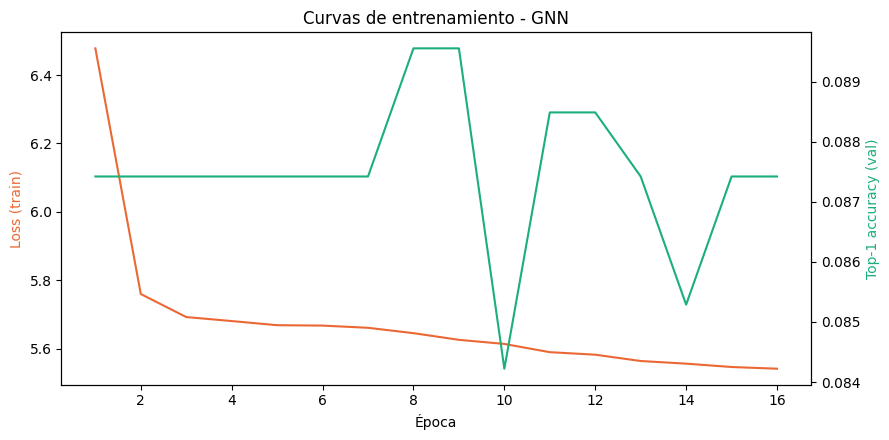

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax2 = ax1.twinx()
ax1.plot(historial_gnn["epoca"], historial_gnn["loss_train"], color="#eb6834", label="Loss (train)")
ax2.plot(historial_gnn["epoca"], historial_gnn["acc_val"], color="#1baf7a", label="Top-1 accuracy (val)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss (train)", color="#eb6834")
ax2.set_ylabel("Top-1 accuracy (val)", color="#1baf7a")
ax1.set_title("Curvas de entrenamiento - GNN")
plt.tight_layout()
plt.show()

### 4.6 Evaluación final sobre `test`

In [ ]:
modelo_gnn.load_state_dict(torch.load(RUTA_MEJOR_MODELO_GNN, map_location=dispositivo))
modelo_gnn.eval()

with torch.no_grad():
    emb_final = modelo_gnn.calcular_embeddings_estructurales(
        atributos_nodo_tensor, indices_origen, indices_destino, norma_gcn
    )

def evaluar_modelo_topk_gnn(modelo, dataloader, dispositivo, emb, k_max=10):
    aciertos = {1: 0, 5: 0, 10: 0}
    total = 0
    for contexto, mascara, objetivo in dataloader:
        contexto, mascara, objetivo = contexto.to(dispositivo), mascara.to(dispositivo), objetivo.to(dispositivo)
        with torch.no_grad():
            logits = modelo(contexto, mascara, emb)
            top_k = logits.topk(k_max, dim=1).indices
        for k in aciertos:
            aciertos[k] += (top_k[:, :k] == objetivo.unsqueeze(1)).any(dim=1).sum().item()
        total += objetivo.size(0)
    return {f"top_{k}_accuracy": v / total for k, v in aciertos.items()}

resultados_gnn = evaluar_modelo_topk_gnn(modelo_gnn, dl_test, dispositivo, emb_final)
print("Modelo GNN: resultados sobre test:")
for metrica, valor in resultados_gnn.items():
    print(f"  {metrica}: {valor:.4f} ({100*valor:.1f}%)")

Modelo GNN: resultados sobre test:
  top_1_accuracy: 0.0970 (9.7%)
  top_5_accuracy: 0.1695 (17.0%)
  top_10_accuracy: 0.1823 (18.2%)


### 4.7 Comparación de las tres familias de modelos

In [ ]:
RUTA_RESULTADOS = os.path.join(RUTA_DATOS, "resultados")
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion2_markov.json")) as f:
    resultados_seccion2 = json.load(f)
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion3_atencion.json")) as f:
    resultados_seccion3 = json.load(f)

tabla_comparativa_gnn = pd.DataFrame({
    "Markov suavizado (baseline)": resultados_seccion2["markov_orden_1_suavizado"],
    "Atención (Sección 3)": resultados_seccion3["resultados_test"],
    "GNN (Sección 4)": resultados_gnn,
}).T
tabla_comparativa_gnn = (tabla_comparativa_gnn * 100).round(2)
tabla_comparativa_gnn.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_comparativa_gnn.to_string())

                             Top-1 (%)  Top-5 (%)  Top-10 (%)
Markov suavizado (baseline)       6.61      16.20       19.94
Atención (Sección 3)              9.06      17.06       18.55
GNN (Sección 4)                   9.70      16.95       18.23


### 4.8 Desempeño por estrato: ¿el GNN resuelve el trade-off de la Sección 3?

In [ ]:
frecuencia_train_dict = train["nodo_nuevo"].value_counts().to_dict()

def estrato_de_frecuencia(nodo, frecuencia_dict, cortes=(50, 10)):
    f = frecuencia_dict.get(nodo, 0)
    if f >= cortes[0]:
        return "alta (≥50 activaciones en train)"
    elif f >= cortes[1]:
        return "media (10-49 activaciones en train)"
    else:
        return "baja (<10 activaciones en train)"

todos_contextos, todas_mascaras, todos_objetivos = [], [], []
for contexto, mascara, objetivo in dl_test:
    todos_contextos.append(contexto)
    todas_mascaras.append(mascara)
    todos_objetivos.append(objetivo)
todos_contextos = torch.cat(todos_contextos).to(dispositivo)
todas_mascaras = torch.cat(todas_mascaras).to(dispositivo)
todos_objetivos = torch.cat(todos_objetivos).to(dispositivo)

with torch.no_grad():
    logits_todos = modelo_gnn(todos_contextos, todas_mascaras, emb_final)
    top_k_todos = logits_todos.topk(10, dim=1).indices

estratos_objetivo = [
    estrato_de_frecuencia(idx_a_nodo[o.item()], frecuencia_train_dict) for o in todos_objetivos
]
estratos_unicos = sorted(set(estratos_objetivo))

resultados_gnn_por_estrato = {}
for estrato in estratos_unicos:
    idxs = [i for i, e in enumerate(estratos_objetivo) if e == estrato]
    obj_sub = todos_objetivos[idxs]
    topk_sub = top_k_todos[idxs]
    aciertos = {1: 0, 5: 0, 10: 0}
    for k in aciertos:
        aciertos[k] = (topk_sub[:, :k] == obj_sub.unsqueeze(1)).any(dim=1).sum().item()
    resultados_gnn_por_estrato[estrato] = {f"top_{k}_accuracy": v / len(idxs) for k, v in aciertos.items()}

tabla_estratos_gnn = (pd.DataFrame(resultados_gnn_por_estrato).T * 100).round(2)
tabla_estratos_gnn.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print("GNN (Sección 4) por estrato:")
print(tabla_estratos_gnn.to_string())
print()
print("Atención (Sección 3) por estrato, para comparar:")
tabla_estratos_atencion_ref = (pd.DataFrame(resultados_seccion3["resultados_test_por_estrato"]).T * 100).round(2)
tabla_estratos_atencion_ref.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_estratos_atencion_ref.to_string())

GNN (Sección 4) por estrato:
                                     Top-1 (%)  Top-5 (%)  Top-10 (%)
alta (≥50 activaciones en train)         55.49      93.90       97.56
baja (<10 activaciones en train)          0.00       0.00        0.00
media (10-49 activaciones en train)       0.00       1.95        4.28

Atención (Sección 3) por estrato, para comparar:
                                     Top-1 (%)  Top-5 (%)  Top-10 (%)
alta (≥50 activaciones en train)         51.83      97.56       99.39
baja (<10 activaciones en train)          0.00       0.00        0.00
media (10-49 activaciones en train)       0.00       0.00        4.28


### 4.9 Guardar resultados

In [ ]:
resultados_gnn_completos = {
    "n_parametros_modelo": n_parametros_gnn,
    "mejor_top1_val": mejor_val_acc_gnn,
    "resultados_test": resultados_gnn,
    "resultados_test_por_estrato": resultados_gnn_por_estrato,
    "historial_entrenamiento": historial_gnn,
}
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion4_gnn.json"), "w") as f:
    json.dump(resultados_gnn_completos, f, indent=2)

print(f"Resultados guardados en {RUTA_RESULTADOS}/resultados_seccion4_gnn.json")

Resultados guardados en /content/drive/MyDrive/semilleroGUIA/datos-redes-sismos/resultados/resultados_seccion4_gnn.json


---
# Sección 5: Comparación final y reporte

esta sección solo consolida resultados ya guardados en las
secciones anteriores. Puede correrse en cualquier momento después de completar las
Secciones 2, 3 y 4, sin necesidad de repetir el entrenamiento.

### 5.0 Cargar todos los resultados guardados

In [ ]:
RUTA_RESULTADOS = os.path.join(RUTA_DATOS, "resultados")

with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion2_markov.json")) as f:
    resultados_seccion2 = json.load(f)
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion3_atencion.json")) as f:
    resultados_seccion3 = json.load(f)
with open(os.path.join(RUTA_RESULTADOS, "resultados_seccion4_gnn.json")) as f:
    resultados_seccion4 = json.load(f)

print("Resultados cargados de las tres secciones de modelado.")

Resultados cargados de las tres secciones de modelado.


### 5.1 Tabla comparativa global

In [ ]:
tabla_final = pd.DataFrame({
    "Aleatorio uniforme": resultados_seccion2["aleatorio_uniforme"],
    "Frecuencia pura": resultados_seccion2["frecuencia_pura"],
    "Markov suavizado (baseline)": resultados_seccion2["markov_orden_1_suavizado"],
    "Atención (Sección 3)": resultados_seccion3["resultados_test"],
    "GNN (Sección 4)": resultados_seccion4["resultados_test"],
}).T
tabla_final = (tabla_final * 100).round(2)
tabla_final.columns = ["Top-1 (%)", "Top-5 (%)", "Top-10 (%)"]
print(tabla_final.to_string())

                             Top-1 (%)  Top-5 (%)  Top-10 (%)
Aleatorio uniforme                0.00       0.32        0.96
Frecuencia pura                   9.91      17.06       18.66
Markov suavizado (baseline)       6.61      16.20       19.94
Atención (Sección 3)              9.06      17.06       18.55
GNN (Sección 4)                   9.70      16.95       18.23


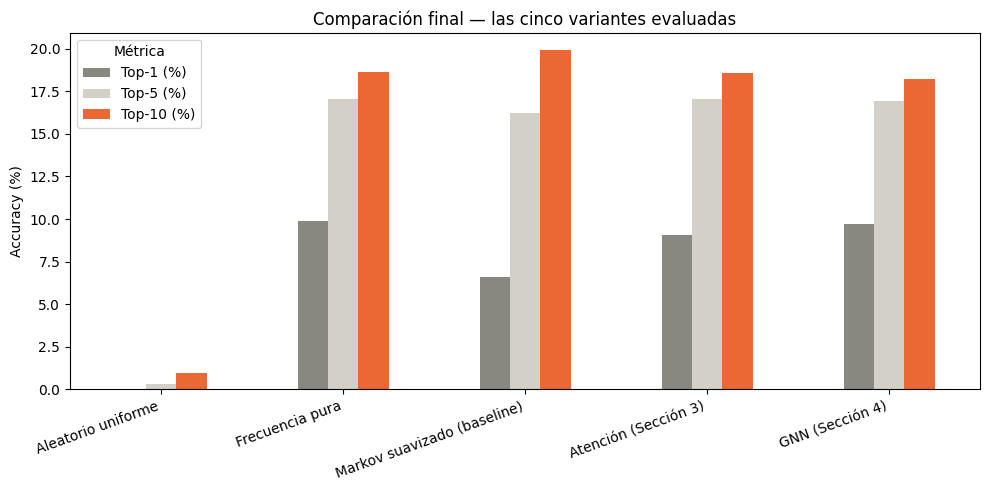

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
tabla_final.plot(kind="bar", ax=ax, color=["#888780", "#d3d1c7", "#eb6834", "#2a78d6", "#1baf7a"])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Comparación final — las cinco variantes evaluadas")
ax.legend(title="Métrica")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 5.2 Tabla comparativa por estrato de frecuencia

La tabla más importante del informe final — el promedio global (5.1) puede ocultar
que un modelo mejor "en promedio" en realidad solo mejora en los hubs y empeora en
la cola larga, tal como se documentó en las Secciones 3 y 4.

In [ ]:
estratos_unicos = sorted(resultados_seccion2["markov_suavizado_por_estrato"].keys())

filas = []
for estrato in estratos_unicos:
    filas.append({
        "estrato": estrato,
        "Markov suavizado - Top-1": resultados_seccion2["markov_suavizado_por_estrato"][estrato]["top_1_accuracy"] * 100,
        "Atención - Top-1": resultados_seccion3["resultados_test_por_estrato"].get(estrato, {}).get("top_1_accuracy", np.nan) * 100,
        "GNN - Top-1": resultados_seccion4["resultados_test_por_estrato"].get(estrato, {}).get("top_1_accuracy", np.nan) * 100,
        "Markov suavizado - Top-10": resultados_seccion2["markov_suavizado_por_estrato"][estrato]["top_10_accuracy"] * 100,
        "Atención - Top-10": resultados_seccion3["resultados_test_por_estrato"].get(estrato, {}).get("top_10_accuracy", np.nan) * 100,
        "GNN - Top-10": resultados_seccion4["resultados_test_por_estrato"].get(estrato, {}).get("top_10_accuracy", np.nan) * 100,
    })
tabla_final_estratos = pd.DataFrame(filas).set_index("estrato").round(2)
print(tabla_final_estratos.to_string())

                                     Markov suavizado - Top-1  Atención - Top-1  GNN - Top-1  Markov suavizado - Top-10  Atención - Top-10  GNN - Top-10
estrato                                                                                                                                                 
alta (≥50 activaciones en train)                        33.54             51.83        55.49                      92.07              99.39         97.56
baja (<10 activaciones en train)                         0.00              0.00         0.00                       1.16               0.00          0.00
media (10-49 activaciones en train)                      2.72              0.00         0.00                      11.67               4.28          4.28


### 5.3 Discusión de resultados

Los resultados fueron:

| Modelo | Top-1 | Top-5 | Top-10 |
|---|---|---|---|
| Markov suavizado (baseline) | 6.6% | 16.2% | 19.9% |
| Atención (Sección 3) | 9.1% | 17.1% | 18.6% |
| GNN (Sección 4) | 9.7% | 17.0% | 18.2% |

Ninguno de los dos modelos más complejos logró superar claramente al modelo base de
Markov. En Top-10, que es la métrica más importante, el baseline incluso queda por
encima de los otros dos.

Al mirar los resultados por estrato de frecuencia, se ve más claro qué está pasando:
tanto atención como GNN mejoran bastante sobre Markov en los nodos de alta frecuencia
(los "hubs" como el nido de Bucaramanga), pero en los nodos de frecuencia media y baja
los tres modelos caen a 0% o casi 0%. Es decir, la mejora que sí hay está concentrada
solo en los nodos que ya eran fáciles de predecir.

Esto tiene sentido si se piensa en la cantidad de datos: como se vio en el EDA, la
mayoría de los nodos solo aparecieron 1 o 2 veces en el entrenamiento. Con tan pocos
ejemplos, ni el modelo de atención ni el GNN tienen cómo aprender algo útil sobre esos
nodos, sin importar qué tan sofisticada sea su arquitectura.

El GNN, que además usa información de la posición geográfica y de la estructura del
grafo, terminó con resultados casi idénticos a los de atención. Esto sugiere que el
problema no era falta de información (geografía, vecinos en el grafo), sino
simplemente falta de ejemplos de entrenamiento para la mayoría de los nodos.

**Conclusión:** con los datos disponibles actualmente, no se encontró evidencia de que
los modelos de atención o de grafos mejoren la predicción de forma general frente a un
modelo simple de transición entre nodos. La señal predictiva que sí existe está
concentrada en los hubs más frecuentes, que ya eran identificables con un modelo
mucho más simple. Como se documentó antes, los datos usados aquí cubren menos nodos
de los que reporta el paper original para el mismo tamaño de celda, así que es
posible que con el catálogo completo estos resultados cambien.

### 5.4 Guardar la tabla final consolidada

In [ ]:
tabla_final.to_csv(os.path.join(RUTA_RESULTADOS, "tabla_comparativa_final.csv"))
tabla_final_estratos.to_csv(os.path.join(RUTA_RESULTADOS, "tabla_comparativa_final_por_estrato.csv"))

print(f"Tablas finales guardadas en {RUTA_RESULTADOS}/")
print("  tabla_comparativa_final.csv")
print("  tabla_comparativa_final_por_estrato.csv")
print()
print("Estas dos tablas son el insumo directo para la sección de resultados del "
      "informe de semillero.")

Tablas finales guardadas en /content/drive/MyDrive/semilleroGUIA/datos-redes-sismos/resultados/
  tabla_comparativa_final.csv
  tabla_comparativa_final_por_estrato.csv

Estas dos tablas son el insumo directo para la sección de resultados del informe de tesis/semillero.
